# Initialization

In [7]:
import stim
import itertools
import logging
import random
import pandas as pd
import os



from concurrent.futures import ProcessPoolExecutor

from wrappers.polar_wrapper import (
    polar_code_p2, get_logical_error_on_accepted_states, divide_half_list
)

from wrappers.qiskit_wrapper import (
    used_qubits
)

from wrappers.stim_wrapper import (simulate_stim_polar_code, generate_circuit_extraction_syndrome, generate_circuit_extraction_syndrome_stim, simulate_batch_and_save_result_polar,
                           calculate_logical_error_result_polar, 
                           convert_i_to_meas_type, noisy_cx, noisy_h, noisy_x, noisy_z, noisy_reset, noisy_measurement,
                           generate_qiskit_polar_code, compiled_to_qiskit_hardware, get_backend_information,
                           generate_circuit_extraction_syndrome_stim_normal, 
                           create_circuit_polar_stim_normal,
                           simulate_stim_polar_code_normal,
                           simulate_batch_and_save_result_polar_normal,
                           calculate_logical_error_result_polar_normal,
                           compile_circuit_qiskit_to_stim,
                           create_circuit_polar_stim_from_qiskit,
                           simulate_stim_polar_code_normal_from_qiskit_circuit,
                           simulate_batch_and_save_result_polar_qiskit,
                           calculate_logical_error_result_polar_qiskit,
                           combine_data, find_and_delete_files,
                           create_sabre_na_pm, check_for_mismatch)

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler import Layout
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
import copy 


In [8]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, Session, Options, Sampler, SamplerV2, RuntimeEncoder, RuntimeDecoder
from qiskit_aer import AerSimulator, QasmSimulator, Aer

token = "9zsMDJr2D381yK6A2fmx2Aqq4mnVaD9RA0Uh49It39UF"
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=token, instance="free", overwrite=True)
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=token, instance="free")

# hw_name = "ibm_brisbane"
hw_name = "ibm_fez"
backend = service.backend(hw_name)

sim_ideal = AerSimulator()
sim_noisy = AerSimulator.from_backend(backend)

## change later back to 3
pm = generate_preset_pass_manager(
    optimization_level=3, backend=backend
    #, seed_transpiler=12345
    )

qiskit_runtime_service._discover_account:WARNING:2026-05-18 23:37:53,296: Loading account with the given token. A saved account will not be used.


# Stim Simulation Normal

## Toy Example

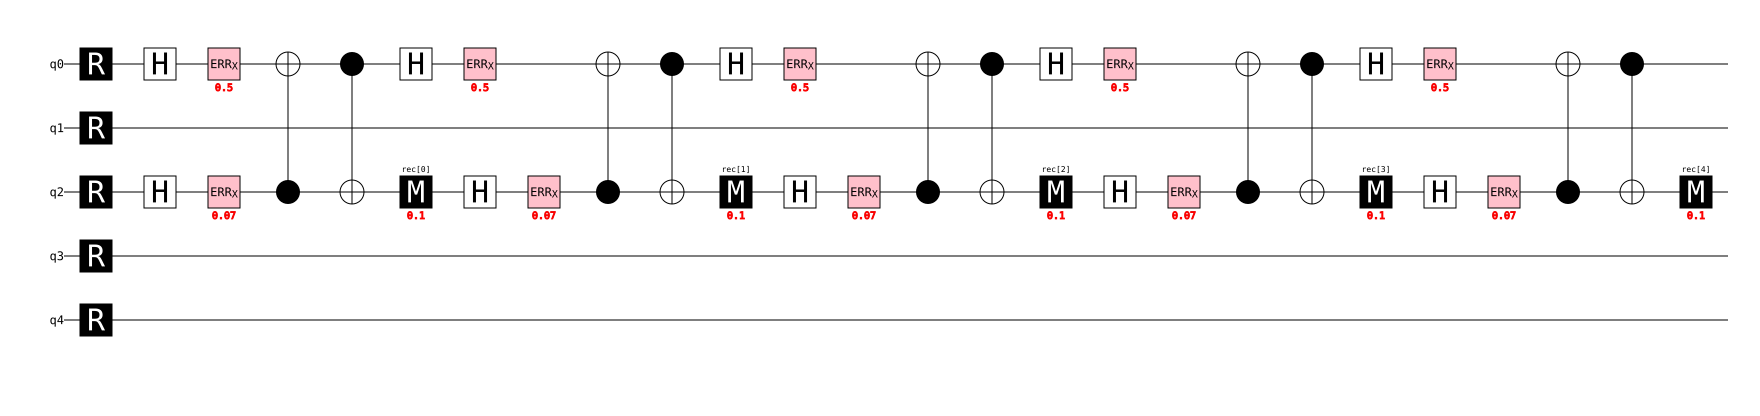

In [4]:
# manual polar_n3_x
circuit = stim.Circuit()

# First, the circuit will initialize a Bell pair.
circuit.append("R", range(0,5))

for i in range(5):

    circuit.append("H", [0,2])
    circuit.append("X_ERROR", [0], [0.5] )
    circuit.append("X_ERROR", [2], [0.07] )
    # noisy_circuit.append("X_ERROR", ins.targets_copy(), p_error)
    # circuit.append("H", [5])
    circuit.append("CNOT", [2, 0])
    circuit.append("CNOT", [0, 2],)
    circuit.append("MZ", [2], 0.1)
    # circuit.append("M", [0, 2])




circuit.diagram("timeline-svg")


### Noiseless

In [5]:
# manual polar_n3_x
circuit = stim.Circuit()

# First, the circuit will initialize a Bell pair.
circuit.append("R", range(0,12))

circuit.append("H", [2,5,8,11])
circuit.append("CNOT", [2, 0, 5, 3, 8, 6, 11, 9])
circuit.append("CNOT", [2, 1, 5, 4, 8, 7, 11, 10])
circuit.append("H", [2,5,8,11])
circuit.append("M", [2,5,8,11])

circuit.append("R", [2,5,8,11])
circuit.append("CNOT", [0, 2, 1, 5, 6, 8, 7, 11])
circuit.append("CNOT", [3, 2, 4, 5, 9, 8, 10, 11])
circuit.append("M", [2,5,8,11])

circuit.append("R", [2,5,8,11])
circuit.append("H", [2,5,8,11])
circuit.append("CNOT", [2, 0, 5, 1, 8, 3, 11, 4])
circuit.append("CNOT", [2, 6, 5, 7, 8, 9, 11, 10])
circuit.append("H", [2,5,8,11])
circuit.append("M", [2,5,8,11])

circuit.append("H", [0,1,3,4,6,7,9,10])
circuit.append("M", [0,1,3,4,6,7,9,10])


In [6]:
data = [2, 0, 5, 3, 8, 6, 11, 9]

# Zip the list with a slice of itself starting from the second element
for x1, x2 in zip(data[::2], data[1::2]):
    print(f"x1 = {x1}, x2 = {x2}")

x1 = 2, x2 = 0
x1 = 5, x2 = 3
x1 = 8, x2 = 6
x1 = 11, x2 = 9


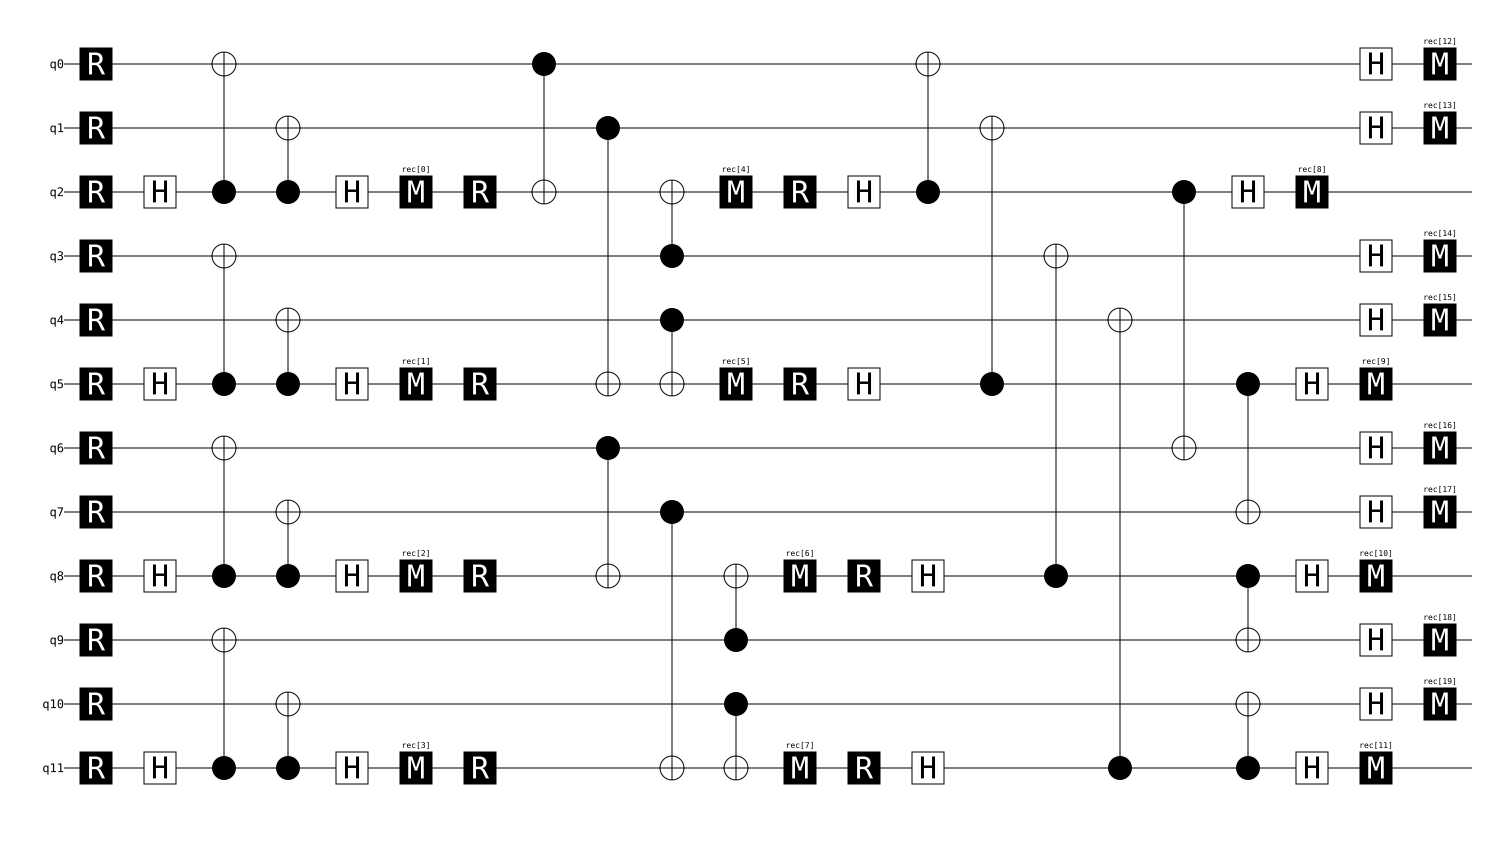

In [7]:
circuit.diagram("timeline-svg")

In [8]:
sampler = circuit.compile_sampler(seed=1)
results = sampler.sample(shots=int(1e4) )

res_bit_string = {}
for res in results:
    bit_string = ""
    for i in res:
        if i:
            bit_string = "1" + bit_string 
        else:
            bit_string = "0" + bit_string

    if bit_string in res_bit_string:
        res_bit_string[bit_string] = res_bit_string[bit_string] + 1
    else:
        res_bit_string[bit_string] = 1

n = 3
lstate = "X"
get_logical_error_on_accepted_states(n, lstate, res_bit_string)


(10000, 0, 0, 1.0, 0, 0.5223978030044236)

### Noisy

In [9]:
def add_stim_error(circuit: stim.Circuit, p_error):
    noisy_circuit = stim.Circuit()

    for ins in circuit:
        used_qubits = []
        idle_qubits = []

        if ins.name != "M":
            noisy_circuit.append(ins)
        
        # TICK doesn't have an error
        if ins.name == "TICK":
            continue
        
        if ins.name == "H":
            noisy_circuit.append("X_ERROR", ins.targets_copy(), p_error)
        elif ins.name == "CX":
            noisy_circuit.append("DEPOLARIZE2", ins.targets_copy(), p_error)
        elif ins.name == "M":
            noisy_circuit.append("X_ERROR", ins.targets_copy(), p_error)
        elif ins.name == "R":
            noisy_circuit.append("X_ERROR", ins.targets_copy(), p_error)

        for qt in ins.targets_copy():
            used_qubits.append(qt.value)

        for i in range(circuit.num_qubits):
            if i not in used_qubits:
                idle_qubits.append(stim.GateTarget(i))

        if ins.name == "M":
            noisy_circuit.append(ins)
        
        if len(idle_qubits) > 1:
            noisy_circuit.append("DEPOLARIZE1", idle_qubits, p_error)    

    return noisy_circuit

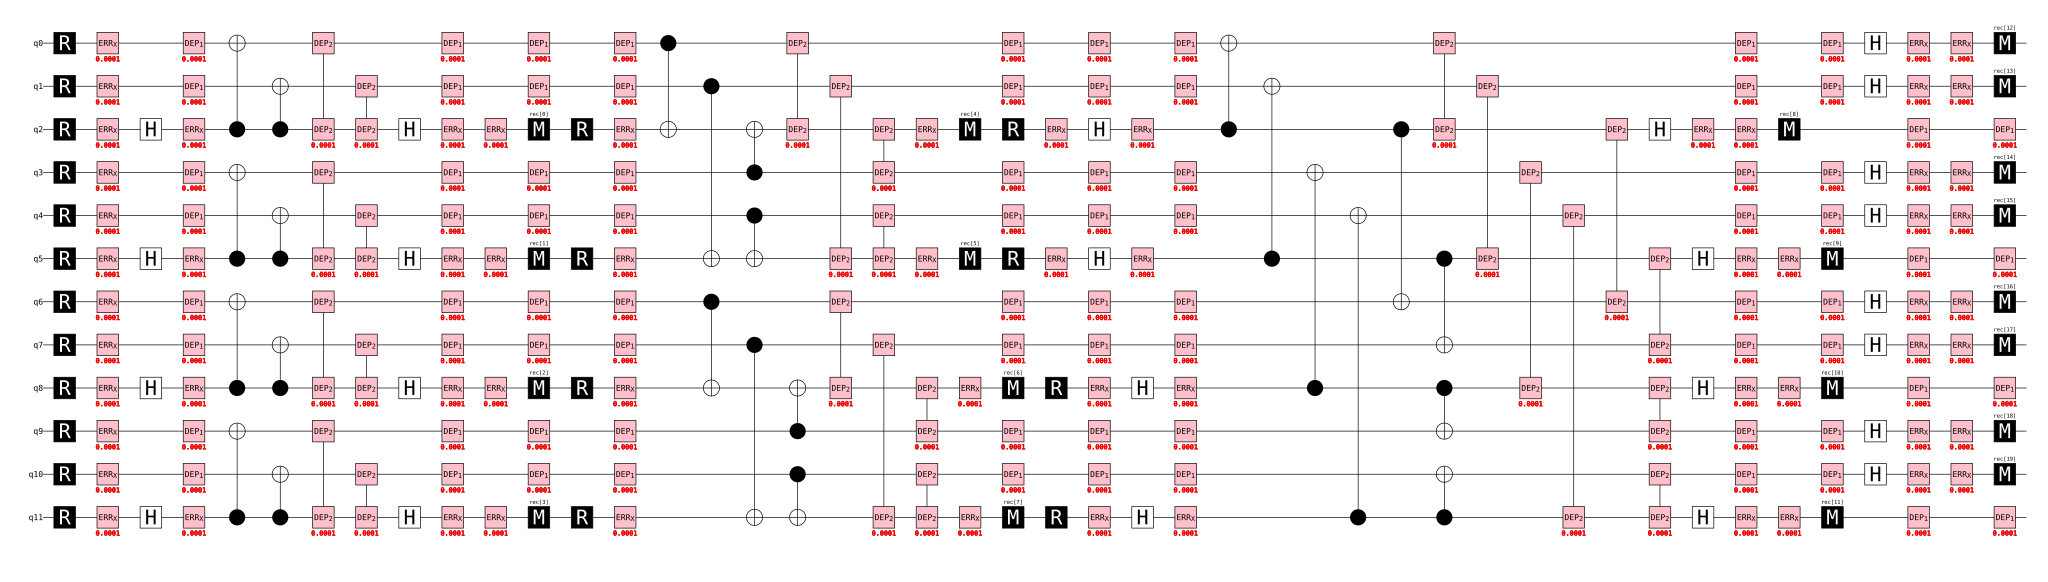

In [10]:
noisy_circuit = add_stim_error(circuit, 0.0001)
noisy_circuit.diagram("timeline-svg")


In [11]:
sampler = noisy_circuit.compile_sampler(seed=1)
results = sampler.sample(shots=int(1e4) )

res_bit_string = {}
for res in results:
    bit_string = ""
    for i in res:
        if i:
            bit_string = "1" + bit_string 
        else:
            bit_string = "0" + bit_string

    if bit_string in res_bit_string:
        res_bit_string[bit_string] = res_bit_string[bit_string] + 1
    else:
        res_bit_string[bit_string] = 1

n = 3
lstate = "X"
get_logical_error_on_accepted_states(n, lstate, res_bit_string)


(9886, 10, 21, 0.9989884685413717, 0, 0.5674818309998955)

## Put into Function

In [12]:
# the code has been moved to stim_wrapper.py

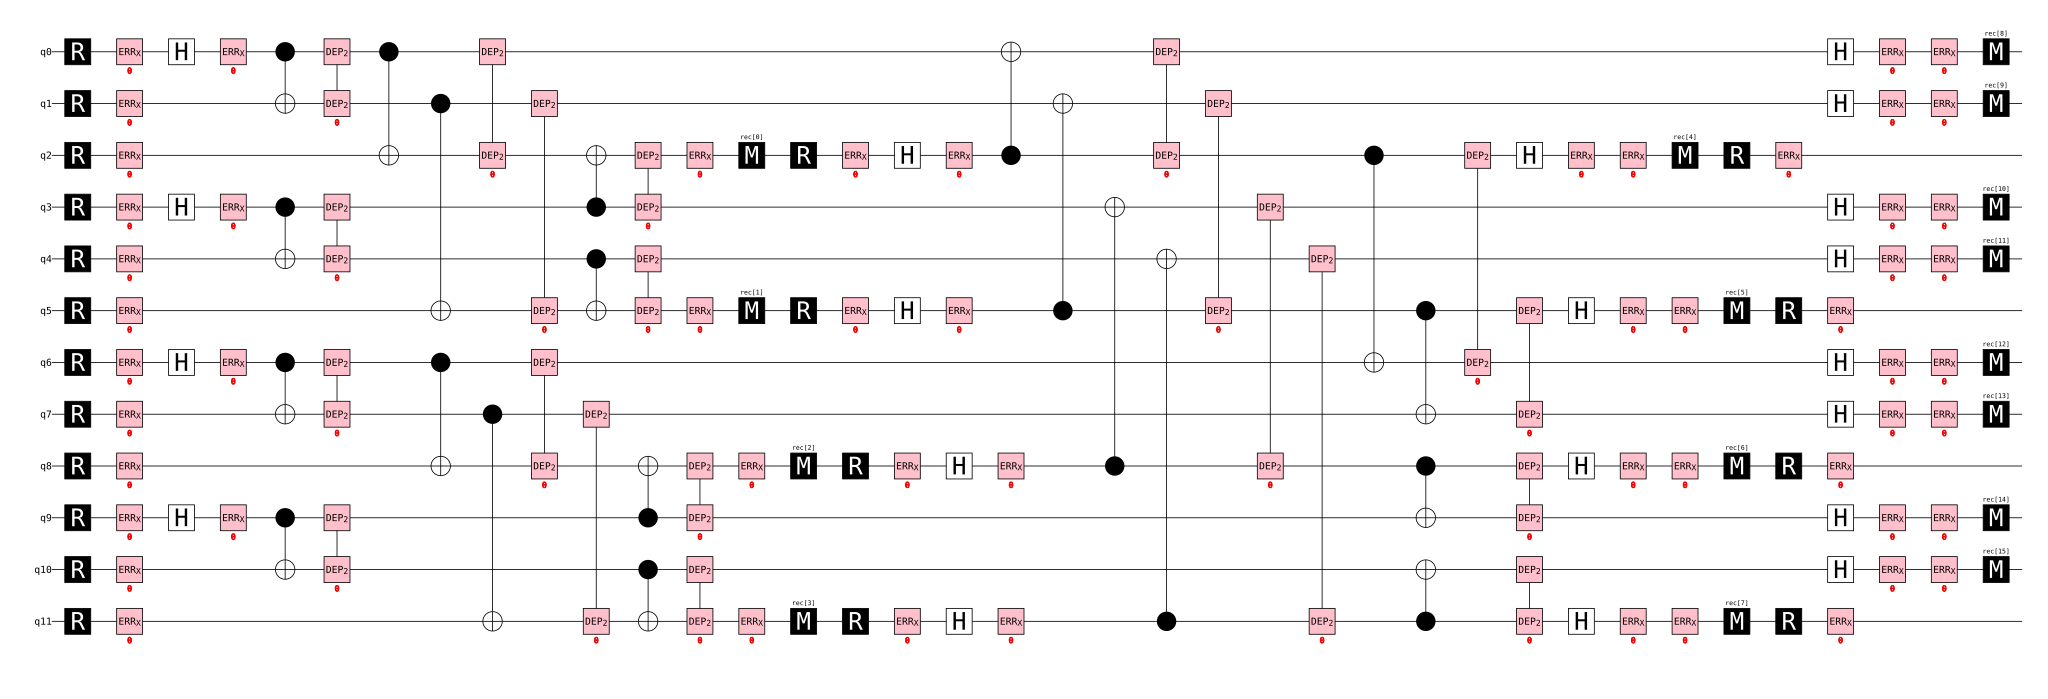

In [13]:
n = 3
i = 4
lstate = "X"
sim_type = "m1"
p_error = 0
shots = int(1e4)
seed = 1

N = 2**(n)
ancilla_qubits = 2**(n - 1)
total_qubits = N + ancilla_qubits

polar_n3 = create_circuit_polar_stim_normal(n, lstate, sim_type, p_error, seed, shots, None, None, None, ["x", "z", "x"], total_qubits, 0)
polar_n3.diagram("timeline-svg")



In [14]:
token = "9zsMDJr2D381yK6A2fmx2Aqq4mnVaD9RA0Uh49It39UF"
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=token, instance="free", overwrite=True)
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=token, instance="free")
hw_name = "ibm_torino"
seed_transpiler = random.randint(1, 9999999)

n = 3
i = 2
lstate = "X"
p_error = 1
shots = int(1e5)
seed = 2

backend = service.backend(hw_name)
qc = generate_qiskit_polar_code(n, lstate, sim_type, i)
tqc = compiled_to_qiskit_hardware(qc, backend, 3, seed_transpiler)
initial_layout = tqc.layout.initial_index_layout(filter_ancillas=True)
print(hw_name, seed_transpiler, initial_layout)

t1, t2, error_1q, readout_error, error_2q = get_backend_information(backend)
cm = backend.coupling_map

polar_n3 = create_circuit_polar_stim_normal(n, lstate, sim_type, p_error, seed, shots, error_1q, readout_error, error_2q, ["x", "z", "x"], total_qubits, 0, 
                                            cm = cm, initial_layout = initial_layout)
polar_n3.diagram("timeline-svg")

qiskit_runtime_service._discover_account:WARNING:2026-05-18 08:31:16,587: Loading account with the given token. A saved account will not be used.


QiskitBackendNotFoundError: 'No backend matches the criteria. Learn more about available backends here https://quantum.cloud.ibm.com/docs/en/guides/qpu-information#view-your-resources'

In [93]:
# function to simulate has been moved to stim_wrapper.py

#### Uniform error rate

In [94]:
def simulate_n5_3_x_normal(n, p_error, shots, seed):
    N = 2**n
    ancilla_qubits = 2**(n - 1)
    total_qubits = N + ancilla_qubits

    counts = {}
    bitstrings = []
    # p_error = 0.0001
    # shots = 100000
    
    circuit = stim.Circuit()

    # initialization error
    r_start = []
    for i in range(total_qubits):
        r_start.append(i)

    circuit.append("R", r_start)
    circuit.append("X_ERROR", r_start, p_error)

    # start_idx_list = []
    # for i in range(16):
    #     start_idx = i * 3 
    #     start_idx_list.append(start_idx)

    # generate_circuit_extraction_syndrome_stim_normal(circuit, 1, "z", False, p_error=p_error, start_idx_list=start_idx_list)

    start_idx_list = []
    for i in range(8):
        start_idx = i * 6
        start_idx_list.append(start_idx)

    generate_circuit_extraction_syndrome_stim_normal(circuit, 2, "x", False, p_error=p_error, start_idx_list=start_idx_list)
        
    start_idx_list = []
    for i in range(4):
        start_idx = i * 12 
        start_idx_list.append(start_idx)
                              
    generate_circuit_extraction_syndrome_stim_normal(circuit, 3, "x", False, p_error=p_error, start_idx_list=start_idx_list)

    start_idx_list = []
    for i in range(2):
        start_idx = i * 24 
        start_idx_list.append(start_idx)

    generate_circuit_extraction_syndrome_stim_normal(circuit, 4, "x", False, p_error=p_error, start_idx_list=start_idx_list)

    start_idx_list = []
    for i in range(1):
        start_idx = i * 48 
        start_idx_list.append(start_idx)

    generate_circuit_extraction_syndrome_stim_normal(circuit, 5, "x", False, p_error=p_error, start_idx_list=start_idx_list)

    # Final measurements
    h_last = []
    m_last = []
    for qb_idx in (j for j in range(total_qubits) if j % 3 != 2):
        if lstate.lower() == "x":
            h_last.append(qb_idx)
        m_last.append(qb_idx)
        
    circuit.append("H", h_last)
    circuit.append("X_ERROR", h_last, p_error)

    circuit.append("M", m_last) 
    circuit.append("X_ERROR", m_last, p_error)

    sampler = circuit.compile_sampler(seed=seed)
    results = sampler.sample(shots=int(shots) )

    counts = {}
    for res in results:
        bit_string = ""
        for i in res:
            if i:
                bit_string = "1" + bit_string 
            else:
                bit_string = "0" + bit_string

        # if sim_type in ["m1", "m2"]:
        #     bit_string = bit_string + "0"*(2**(n - 1))

        if bit_string in counts:
            counts[bit_string] = counts[bit_string] + 1
        else:
            counts[bit_string] = 1   


    return counts, bitstrings, circuit


In [95]:
def simulate_n5_3_x_proposal(n, p_error, shots, seed):
    N = 2**n
    ancilla_qubits = 2**(n - 1)
    total_qubits = N + ancilla_qubits

    counts = {}
    bitstrings = []
    # p_error = 0.0001
    # shots = 100000
    
    circuit = stim.Circuit()

    # initialization error
    r_start = []
    for i in range(total_qubits):
        r_start.append(i)

    circuit.append("R", r_start)
    circuit.append("X_ERROR", r_start, p_error)

    # 3 = zxxxx
    start_idx_list = []
    # for i in range(8):
    #     start_idx = i * 3 
    #     start_idx_list.append(start_idx)

    # generate_circuit_extraction_syndrome_stim_normal(circuit, 1, "z", True, p_error=p_error, start_idx_list=start_idx_list)

    # for qb in range(26, 48, 3): 
    #     circuit.append("m", qb)

    start_idx_list = []
    for i in range(8):
        start_idx = i * 6
        start_idx_list.append(start_idx)

    generate_circuit_extraction_syndrome_stim_normal(circuit, 2, "x", True, p_error=p_error, start_idx_list=start_idx_list)

    # for qb in range(26, 48, 3): 
    #     circuit.append("m", qb)
        
    start_idx_list = []
    for i in range(4):
        start_idx = i * 12 
        start_idx_list.append(start_idx)
                              
    generate_circuit_extraction_syndrome_stim_normal(circuit, 3, "x", False, p_error=p_error, start_idx_list=start_idx_list)

    # # Note: jump 6 
    # h_list = []
    # cx_list = []
    # for i in (j for j in range(24, 30) if j % 3 != 2):
    #     h_list.append(i)
    #     cx_list.append(i)
    #     cx_list.append(i+6)
        
    # for i in (j for j in range(35, 41) if j % 3 != 2):
    #     h_list.append(i)
    #     cx_list.append(i)
    #     cx_list.append(i+6)

    # circuit.append("h", h_list)
    # circuit.append("cx", cx_list)

    # for qb in range(26, 48, 3): 
    #     circuit.append("m", qb)


    start_idx_list = []
    for i in range(2):
        start_idx = i * 24 
        start_idx_list.append(start_idx)

    generate_circuit_extraction_syndrome_stim_normal(circuit, 4, "x", False, p_error=p_error, start_idx_list=start_idx_list)

    start_idx_list = []
    for i in range(1):
        start_idx = i * 48 
        start_idx_list.append(start_idx)

    generate_circuit_extraction_syndrome_stim_normal(circuit, 5, "x", False, p_error=p_error, start_idx_list=start_idx_list)

    # Final measurements
    h_last = []
    m_last = []
    for qb_idx in (j for j in range(total_qubits) if j % 3 != 2):
        if lstate.lower() == "x":
            h_last.append(qb_idx)
        m_last.append(qb_idx)
        
    circuit.append("H", h_last)
    circuit.append("X_ERROR", h_last, p_error)

    circuit.append("M", m_last) 
    circuit.append("X_ERROR", m_last, p_error)

    sampler = circuit.compile_sampler(seed=seed)
    results = sampler.sample(shots=int(shots) )

    counts = {}
    for res in results:
        bit_string = ""
        for i in res:
            if i:
                bit_string = "1" + bit_string 
            else:
                bit_string = "0" + bit_string

        
        bit_string = bit_string + "0"*(2**(n - 1))

        if bit_string in counts:
            counts[bit_string] = counts[bit_string] + 1
        else:
            counts[bit_string] = 1   


    return counts, bitstrings, circuit


In [96]:
n = 5
i = 3
p_error = 0
shots = 1000
seed = 1234
counts_normal, bs_normal, circuit_normal = simulate_n5_3_x_normal(n, p_error, shots, seed)
counts_proposal, bs_proposal, circuit_proposal = simulate_n5_3_x_proposal(n, p_error, shots, seed)

zpos_list = [-1, -1, 1, 3, 3, 7, 22, 15, 90, 31, 362]
zpos_list[n] = i-1

n = 5
lstate = "X"
count_accept_n, count_logerror, count_undecided, ler_n, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts_normal, zpos_list)
print(count_accept_n, count_accept_n / shots, 1 - ler_n, count_logerror, count_undecided)

count_accept_p, count_logerror, count_undecided, ler_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts_proposal, zpos_list)
print(count_accept_p, count_accept_p / shots, 1 - ler_p, count_logerror, count_undecided,)


1000 1.0 0.0 0 0
1000 1.0 0.0 0 0


In [97]:
# from qiskit import QuantumCircuit
# from qiskit.quantum_info import Statevector
# from qiskit.visualization import plot_bloch_multivector
 
# qc = QuantumCircuit(1)
# qc.x(0)
# qc.t(0)
 
# state = Statevector(qc)
# plot_bloch_multivector(state)


In [98]:
# from qiskit import QuantumCircuit
# from qiskit.quantum_info import Statevector
# from qiskit.visualization import plot_state_qsphere
# from qiskit import transpile
# from qiskit_aer import AerSimulator

# simulator = AerSimulator()

# qc = QuantumCircuit(1)
# qc.t(0)
# # qc.s(0)

# state = Statevector(qc)
# print(state.data)

# plot_state_qsphere(state)

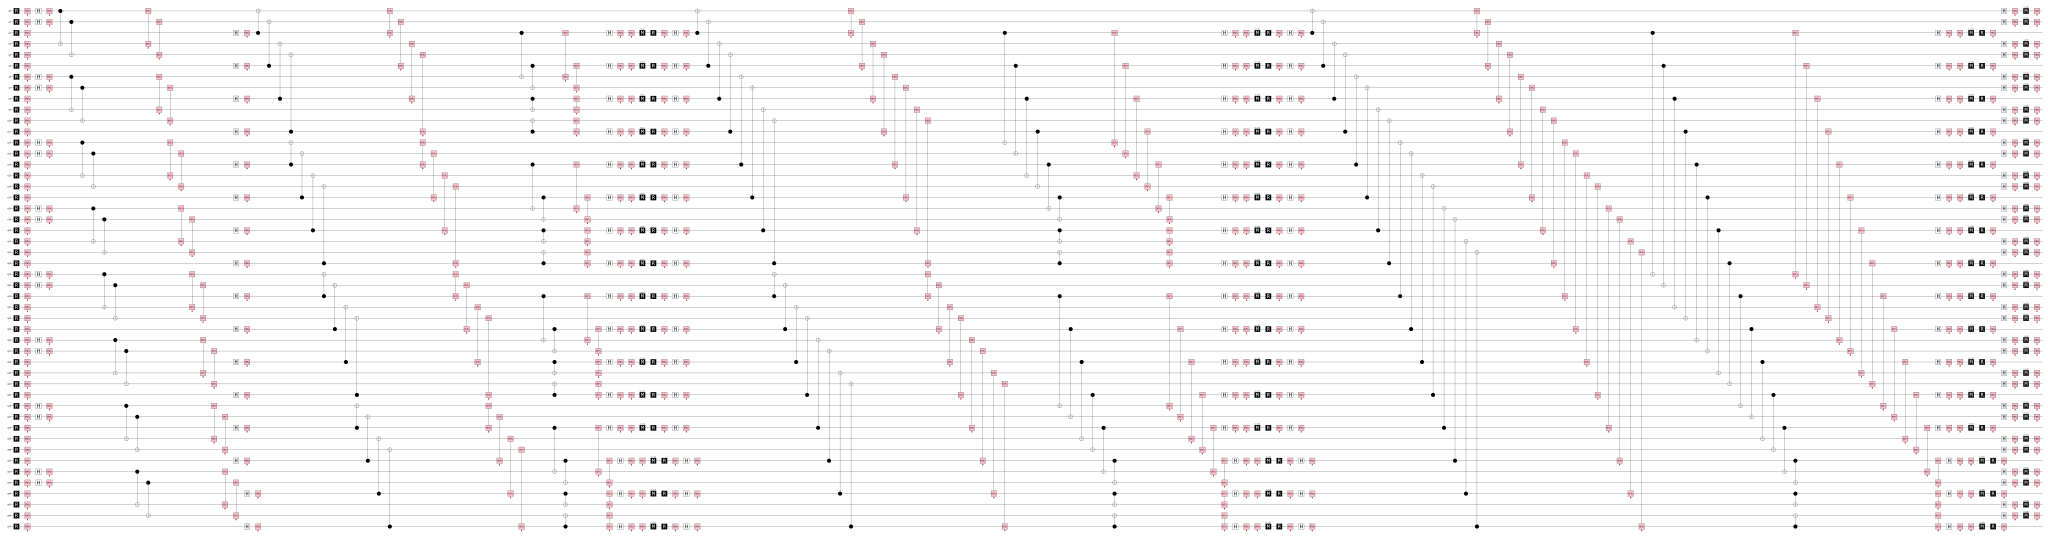

In [99]:
circuit_proposal.diagram("timeline-svg")

In [100]:
n = 4
i = 2
lstate = "X"
p_error = 0.01
shots = int(1e3)
seed = 2

zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
zpos_list[n] = i-1

sim_type = "normal"
counts = simulate_stim_polar_code_normal(n, lstate, sim_type, i, p_error, shots, seed, backend = None, initial_layout = None)
count_accept_p, count_logerror, count_undecided, ler_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts, zpos_list=zpos_list)
print(count_accept_p, count_accept_p / shots, 1 - ler_p, count_logerror, count_undecided,)

sim_type = "m1"
counts = simulate_stim_polar_code_normal(n, lstate, sim_type, i, p_error, shots, seed, backend = None, initial_layout = None)
count_accept_p, count_logerror, count_undecided, ler_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts, zpos_list=zpos_list)
print(count_accept_p, count_accept_p / shots, 1 - ler_p, count_logerror, count_undecided,)


242 0.242 0.0 0 0
309 0.309 0.0 0 0


In [101]:
n = 3
i = 7
lstate = "z"
sim_type = "normal"
p_error = 0.01
shots = int(1e5)
seed = random.randint(1, 9999999)

simulate_batch_and_save_result_polar_normal(n, lstate, sim_type, p_error, i, shots, seed)

{'n': 3,
 'lstate': 'z',
 'i': 7,
 'meas_type': ['x', 'z', 'z'],
 'p_error': 0.01,
 'sim_type': 'normal',
 'total_meta_shots': 0,
 'shots': 100000,
 'count_accept': 68279,
 'count_logerror': 64,
 'count_undecided': 125,
 'count_detect_discard': 0,
 'prep_rate': 0.68279,
 'LER': 0.0009373306580353624,
 'detect_normal': 0,
 'decoding_normal': 3.0084662860026583}

In [102]:
calculate_logical_error_result_polar_normal(n, lstate, i, p_error, sim_type, seed)

#### Non-uniform error rate

In [103]:
token = "9zsMDJr2D381yK6A2fmx2Aqq4mnVaD9RA0Uh49It39UF"

QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=token, instance="free", overwrite=True)
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=token, instance="free")
hw_name = "ibm_torino"
backend = service.backend(hw_name)

qiskit_runtime_service._discover_account:WARNING:2026-03-26 10:55:14,913: Loading account with the given token. A saved account will not be used.


In [104]:
# t1, t2, error_1q, readout_error, error_2q = get_backend_information(backend)

# sim_ideal = AerSimulator()
# sim_noisy = AerSimulator.from_backend(backend)

# noise_model = NoiseModel.from_backend(backend)
# noise_model.add_basis_gates("cx")
# for key, value in error_2q.items():
#     dep_error_2q = depolarizing_error(value, 2)
#     noise_model.add_quantum_error(dep_error_2q, "cx", key )

# noise_model.add_basis_gates("h")
# for key, value in error_1q.items():
#     dep_error_1q = depolarizing_error(value, 1)
#     noise_model.add_quantum_error(dep_error_1q, "h", (key,) )

# properties = backend.properties()
# prop_dict = properties.to_dict()
# new_prop_dict = properties.to_dict().copy()

# for i in prop_dict["gates"]:
#     if(i["gate"] == "cz"):
#         gate_dict = copy.deepcopy(i)
#         gate_dict["gate"] = "cx"

#         new_prop_dict["gates"].append(gate_dict)
        
#     if(i["gate"] == "x"):
#         gate_dict = copy.deepcopy(i)
#         gate_dict["gate"] = "h"

#         new_prop_dict["gates"].append(gate_dict)

# new_prop = properties.from_dict(new_prop_dict)

# sim_noisy_cx = AerSimulator(# configuration=backend.configuration(),
#                             properties=new_prop,
#                             # properties=backend.properties(),
#                             noise_model=noise_model)

In [105]:
# hw_name = "ibm_torino"
# seed_transpiler = random.randint(1, 9999999)
# # seed_transpiler = 12345

# n = 3
# i = 2
# lstate = "X"
# p_error = 0.01
# shots = int(1e4)
# seed = 2
# sim_type = "m1"

# backend = service.backend(hw_name)
# qc = generate_qiskit_polar_code(n, lstate.lower(), sim_type, i)
# tqc = compiled_to_qiskit_hardware(qc, backend, 3, seed_transpiler)
# tqc.draw(fold=-1, idle_wires=False)

In [106]:
# qc.draw("mpl", fold=-1)

##### Converting from Qiskit Layout to STIM

[6, 7, 5, 13, 15, 17, 19, 4, 9, 11, 14, 18, 10, 12, 16, 8]


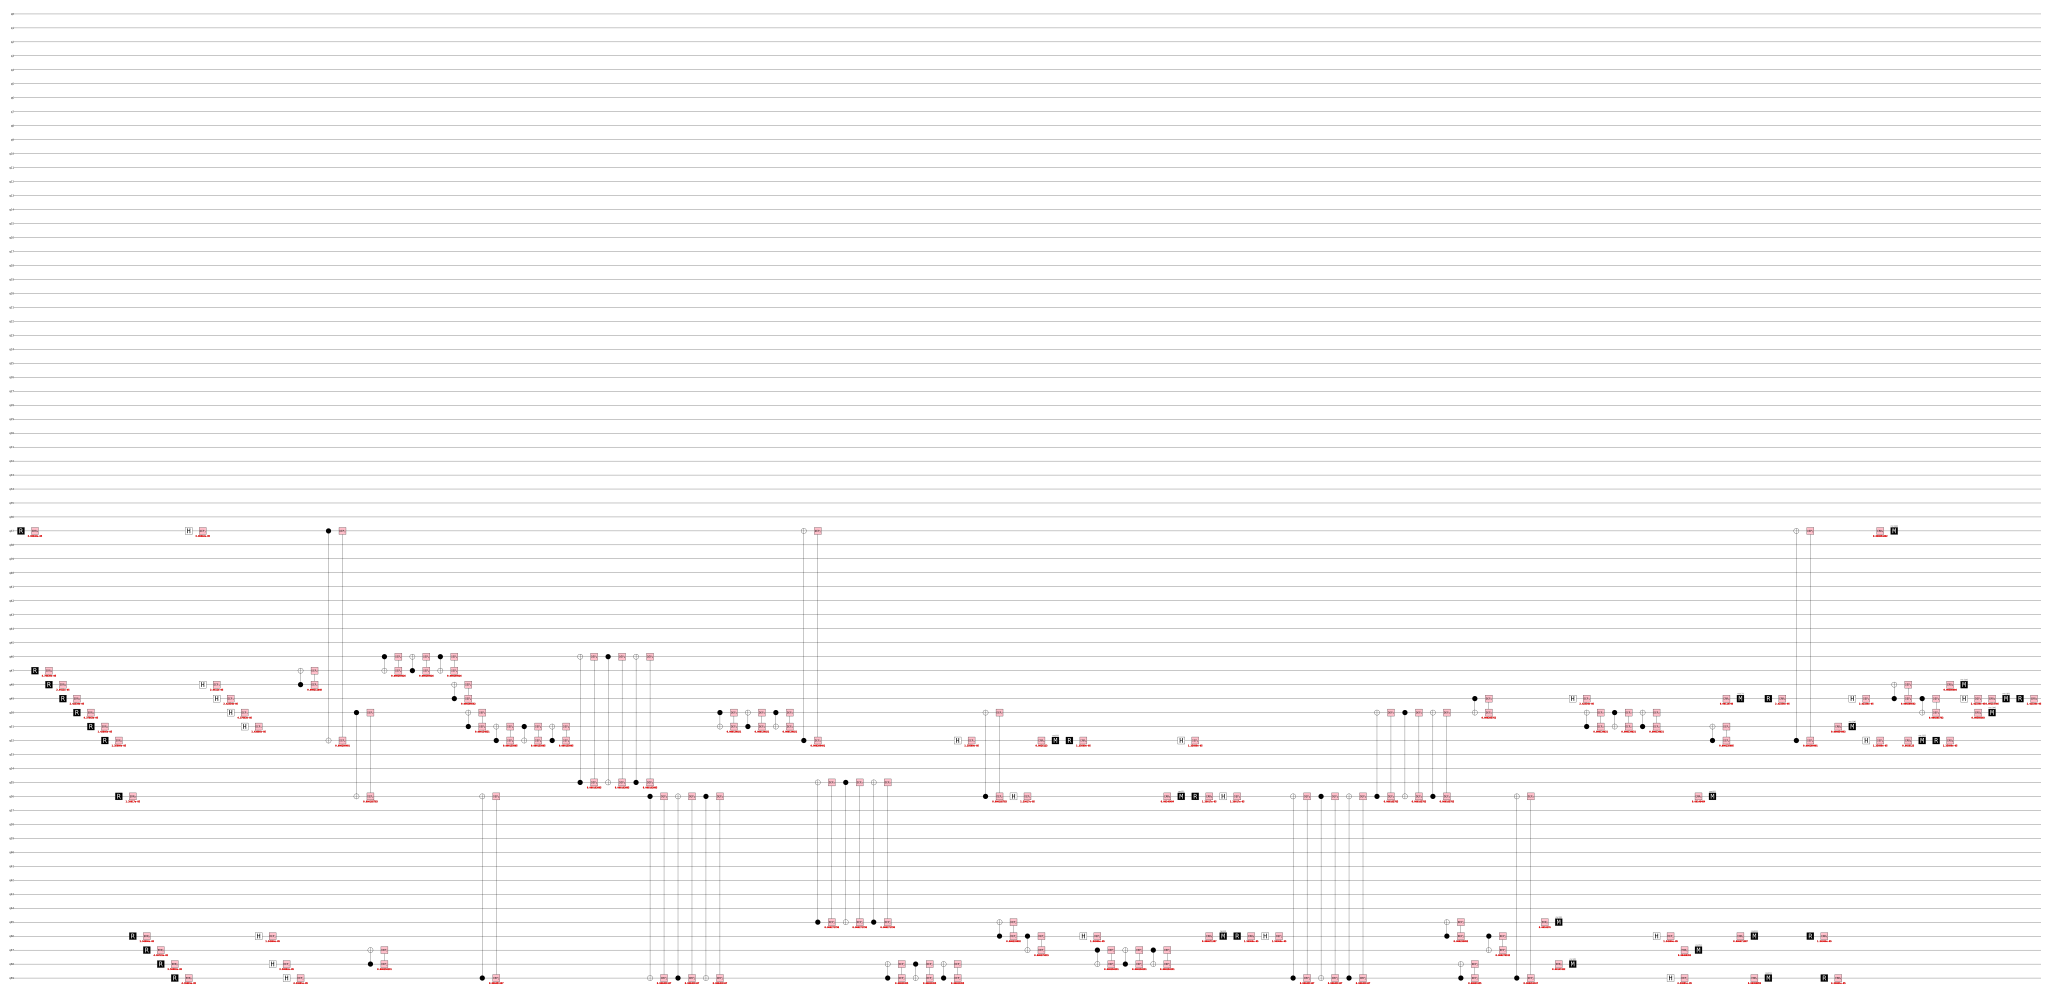

In [107]:
circuit, m_order = compile_circuit_qiskit_to_stim(tqc, backend, 0.1)
print(m_order)
circuit.diagram("timeline-svg")

In [108]:
# # print(m_order)
# sampler = circuit.compile_sampler(seed=1)
# results = sampler.sample(shots=int(1e5) )

# res_bit_string = {}
# for res in results:
#     bit_string = ""
#     for i in res:
#         if i:
#             bit_string = bit_string + "1" 
#         else:
#             bit_string = bit_string + "0"

#     # Create a new list to hold the reordered bits
#     # Initialize it with placeholders (e.g., empty strings)
#     new_bits = [''] * len(bit_string)

#     # Loop through each bit in the original string
#     for i in range(len(bit_string)):
#         # Get the bit from the original string
#         original_bit = bit_string[i]
        
#         # Get the new position for this bit from the order list
#         new_position = m_order[i]
        
#         # Place the bit in its new position
#         new_bits[new_position] = original_bit

#     # Join the list of bits back into a single string
#     reordered_string = "".join(new_bits)[::-1]

#     bit_string = bit_string[::-1]

#     # print(f"Original bitstring:  {bit_string}")
#     # print(f"Reordered bitstring: {reordered_string}")

#     if reordered_string in res_bit_string:
#         res_bit_string[reordered_string] = res_bit_string[reordered_string] + 1
#     else:
#         res_bit_string[reordered_string] = 1

# n = 3
# lstate = "X"
# i = 2
# zpos_list = [-1, -1, 1, i-1, 6, 7, 22, 15, 90, 31, 362]
# get_logical_error_on_accepted_states(n, lstate, res_bit_string, zpos_list)


In [109]:
n = 4
i = 3
lstate = "X"
p_error = 0
shots = int(1e4)
seed = random.randint(1, 9999999)
# seed = 4707440

hw_name = "ibm_torino"
backend = service.backend(hw_name)

# for i in range(2,10):
#     # i = 3
#     zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
#     zpos_list[n] = i-1

#     sim_type = "m1"
#     counts = simulate_stim_polar_code_normal_from_qiskit_circuit(n, lstate, sim_type, i, p_error, shots, seed, backend, "init")
#     count_accept_p, count_logerror, count_undecided, ler_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts, zpos_list=zpos_list)
#     print(count_accept_p, count_accept_p / shots, 1 - ler_p, count_logerror, count_undecided,)

#     sim_type = "m1"
#     counts = simulate_stim_polar_code_normal_from_qiskit_circuit(n, lstate, sim_type, i, p_error, shots, seed, backend, "na")
#     count_accept_p, count_logerror, count_undecided, ler_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts, zpos_list=zpos_list)
#     print(count_accept_p, count_accept_p / shots, 1 - ler_p, count_logerror, count_undecided,)


In [110]:
circuit, m_order = create_circuit_polar_stim_from_qiskit(n, lstate, sim_type, i, p_error, seed, backend, "na")

Mapping properties from native 'cz' to 'cx'...
[NA-3] best_idx =  0 , best cx =  48


In [111]:
sim_type = "m1"

sampler = circuit.compile_sampler(seed=seed)
results = sampler.sample(shots=int(shots) )

res_bit_string = {}
for res in results:
    bit_string = ""

    # if sim_type in ["m1", "m2"]:
    #     bit_string = bit_string + "0"*(2**(n - 1))

    for j in res:
        if j:
            bit_string = bit_string + "1" 
        else:
            bit_string = bit_string + "0"

    # print(len(bit_string), bit_string, m_order)

    new_bits = [''] * len(bit_string)

    # Loop through each bit in the original string
    for j in range(len(bit_string)):
        # Get the bit from the original string
        original_bit = bit_string[j]
        
        # Get the new position for this bit from the order list
        new_position = m_order[j]
        
        # Place the bit in its new position
        new_bits[new_position] = original_bit

    reordered_string = "".join(new_bits)[::-1]


    if reordered_string in res_bit_string:
        res_bit_string[reordered_string] = res_bit_string[reordered_string] + 1
    else:
        res_bit_string[reordered_string] = 1

In [112]:
res_bit_string

{'1011001010111011000010011001000001100101': 1,
 '1001110100101010101101110100100011101000': 2,
 '1101001110011100010011111110010110111111': 1,
 '0001110100101000001101011100101001101010': 1,
 '0100110010111110111100101000010101110101': 2,
 '0101110010001100110100001001010000111011': 1,
 '0101010111010000100001010000110100001000': 1,
 '1011010010001111001110111111011101011000': 1,
 '0001110010101110101100101101010001110001': 1,
 '1100010000101100111010001000111011011011': 1,
 '0001100100100111001111101000010101111010': 1,
 '0011101101100011010110001000010111011111': 1,
 '0101010111111110101010110000000100000001': 2,
 '1101110110101111011100100000010110100000': 1,
 '1111001000101111110111011101110100101000': 1,
 '0011001100100111000101000000010111111010': 1,
 '0100011000100000011001100010001001111000': 1,
 '1011111000101100100100100101111001011011': 1,
 '1100100111110110001111110101100111110011': 1,
 '0111100001010111001011111111001010100010': 1,
 '11000110101100100111010010101001111101

In [113]:
zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
zpos_list[n] = i-1

count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = \
    get_logical_error_on_accepted_states(n, lstate.upper(), res_bit_string, zpos_list=zpos_list)

print(count_accept)

10000


In [114]:
m_order

[1,
 3,
 4,
 5,
 6,
 7,
 0,
 2,
 9,
 14,
 15,
 10,
 12,
 25,
 30,
 13,
 22,
 38,
 17,
 26,
 33,
 8,
 18,
 34,
 11,
 21,
 37,
 29,
 31,
 24,
 28,
 20,
 23,
 27,
 36,
 39,
 19,
 35,
 16,
 32]

In [115]:
print(seed)

7462545


## Combine results

In [9]:
import glob
import sys
import numpy as np
import math

def combine_data(file_pattern, output_filename):
    """
    Finds, combines, and aggregates CSV files based on specified keys.
    """
    print(f"Looking for files matching: {file_pattern}")
    
    # 1. Find all files matching the pattern
    all_files = glob.glob(file_pattern)
    
    # Exclude the output file itself if it matches the pattern
    if output_filename in all_files:
        all_files.remove(output_filename)

    if not all_files:
        print("Error: No files found to combine. Check your FILE_PATTERN.")
        sys.exit()

    print(f"Found {len(all_files)} files. Reading and concatenating...")

    # 2. Load all files into a list of DataFrames
    df_list = []
    for f in all_files:
        try:
            new_df = pd.read_csv(f)
            # Define the condition
            condition = (new_df["count_logerror"] > 0) & (new_df["count_undecided"] > 0)

            # Apply the calculation using np.where
            new_df["count_logerror"] = np.where(
                condition,  # 1. Condition
                round(new_df["count_logerror"] - (new_df["count_undecided"] / 2)), # 2. Value if TRUE (the calculation)
                new_df["count_logerror"] # 3. Value if FALSE (keep the original value)
            )

            df_list.append(new_df)
        except Exception as e:
            print(f"Warning: Could not read {f}. Error: {e}")

    if not df_list:
        print("Error: No files were successfully read.")
        sys.exit()

    # 3. Combine all DataFrames into one
    full_df = pd.concat(df_list, ignore_index=True)
    print("All files concatenated.")

    # 4. Define grouping keys and columns for aggregation
    grouping_keys = ['n', 'lstate', 'i', 'meas_type', 'p_error', 'sim_type']
    
    # These columns represent raw counts and should be SUMMED
    count_columns = [
        'total_meta_shots',
        'shots',
        'count_accept',
        'count_logerror',
        'count_undecided',
        'count_detect_discard',
        'detect_normal',
        'decoding_normal'
    ]
    
    # These columns are rates. We will calculate the MEAN for those
    # whose formula isn't obvious.
    rate_columns = [
        'LER',
    ]

    # Filter lists to only include columns that actually exist in the DataFrame
    present_keys = [col for col in grouping_keys if col in full_df.columns]
    present_counts = [col for col in count_columns if col in full_df.columns]
    present_rates = [col for col in rate_columns if col in full_df.columns]

    print(f"Grouping by: {present_keys}")

    # 5. Perform the aggregation
    
    # First, aggregate counts using sum()
    agg_df_counts = full_df.groupby(present_keys)[present_counts].sum()
    
    # # Second, aggregate unknown rates using mean()
    # agg_df_rates = full_df.groupby(present_keys)[present_rates].mean()
    
    # Join the two aggregated DataFrames back together
    # agg_df = agg_df_counts.join(agg_df_rates).reset_index()
    agg_df = agg_df_counts.reset_index()


    # 6. Recalculate rates based on the new sums
    # From your example, prep_rate = count_accept / shots
    # We use np.where for safe division (avoids dividing by zero)
    
    if 'count_accept' in agg_df.columns and 'shots' in agg_df.columns:
        print("Recalculating 'prep_rate'...")
        agg_df['prep_rate'] = np.where(
            agg_df['shots'] > 0,              # Condition
            agg_df['count_accept'] / agg_df['shots'], # If true
            0                                 # If false
        )

    if 'count_accept' in agg_df.columns and 'shots' in agg_df.columns:
        print("Recalculating 'LER'...")
        agg_df['LER'] = np.where(
            agg_df['count_accept'] > 0,              # Condition
            round(agg_df['count_logerror'] + (agg_df['count_undecided'] / 2) )/ agg_df['count_accept'], # If true
            0                                 # If false
        )
    
    # Re-order columns to match the original input format
    original_order = [
        'n','lstate','i','meas_type','p_error','sim_type',
        'total_meta_shots','shots','count_accept','count_logerror',
        'count_undecided','count_detect_discard','prep_rate','LER',
        'detect_normal','decoding_normal'
    ]
    
    final_columns = [col for col in original_order if col in agg_df.columns]
    agg_df = agg_df[final_columns]

    # 7. Save the final DataFrame to a new CSV
    try:
        agg_df.to_csv(output_filename, index=False)
        print(f"\nSuccess! Combined data saved to: {output_filename}")
        
        # print("\n--- Head of new combined DataFrame ---")
        # print(agg_df.head())
        # print("--------------------------------------")

    except Exception as e:
        print(f"Error saving file: {e}")

In [10]:
import glob
import sys
import numpy as np
import math
import pandas as pd # <-- Make sure to import pandas if it's not already at the top of your actual file!

def convert_to_list(meas_str):
    return meas_str.replace("'","").replace("[","").replace("]","").replace(" ","").split(",")

def count_hadamards(meas_str):
    """
    Counts the total number of Hadamards (based on 'x' occurrences)
    in the flattened measurement sequence.
    """

    measurement_sequence = convert_to_list(meas_str)
    
    n = len(measurement_sequence)
    hadamard_val = pow(2, n)

    # print(n, hadamard_val, measurement_sequence)
    
    # Initialize the count
    count = 0
    
    # Iterate through the sequence and count 'x's
    for measurement in measurement_sequence:
        if measurement == "x":
            # Add the calculated Hadamard value for each 'x'
            count += hadamard_val
            
    return count

def count_skip(meas_str):
    """
    Counts the total number of Hadamards (based on 'x' occurrences)
    in the flattened measurement sequence.
    """

    measurement_sequence = convert_to_list(meas_str)
    
    x_ind = 0
    for idx, m_type in enumerate(measurement_sequence):
        if m_type == "x":
            x_ind = idx
            break
            
    return x_ind


def combine_data(file_pattern, output_filename, comp_type = False):
    """
    Finds, combines, and aggregates CSV files based on specified keys.
    Calculates Standard Error of the Mean (SEM) for prep_rate and LER.
    """
    print(f"Looking for files matching: {file_pattern}")

    # 1. Find all files matching the pattern
    all_files = glob.glob(file_pattern)

    # Exclude the output file itself if it matches the pattern
    if output_filename in all_files:
        all_files.remove(output_filename)

    if not all_files:
        print("Error: No files found to combine. Check your FILE_PATTERN.")
        sys.exit()

    print(f"Found {len(all_files)} files. Reading and concatenating...")

    # # 2. Load all files, calculate individual rates, and then combine
    # df_list = []
    # for f in all_files:
    #     try:
    #         new_df = pd.read_csv(f)
            
    #         # --- 1. Drop existing 'meas_type' column if it exists ---
    #         if 'meas_type' in new_df.columns:
    #             new_df = new_df.drop(columns=['meas_type'])
    #             print(f"   ⬇️ Dropped 'meas_type' column from {f}.")

    #         # --- 2. Remove Duplicate Rows ---
    #         initial_count = len(new_df)
    #         new_df = new_df.drop_duplicates()
            
    #         dropped_count = initial_count - len(new_df)
    #         if dropped_count > 0:
    #             print(f"   🗑️ Removed {dropped_count} duplicate rows from {f}.")
                
    #         # --- 3. FIXING 'meas_type' (Recalculate) ---
    #         # Use .apply(..., axis=1) to pass row values to the function
    #         new_df['meas_type'] = new_df.apply(
    #             lambda row: convert_i_to_meas_type(row['i'], row['n'], row['lstate']), 
    #             axis=1
    #         )
            
    #         # --- 4. OVERWRITING THE FILE ---
    #         # Save the updated DataFrame back to the original file path (f)
    #         new_df.to_csv(f, index=False)
    #         print(f"   ✅ Successfully processed and overwrote: {f}")

            

    #     except Exception as e:
    #         print(f"   ⚠️ Warning: Could not read or process {f}. Error: {e}")

    # print("\nProcessing complete. All relevant files have been cleaned, deduplicated, and updated with the corrected 'meas_type' column.")

    # 2. Load all files, calculate individual rates, and then combine
    df_list = []
    file_idx = 0
    for f in all_files:
        try:
            new_df = pd.read_csv(f)
            n = new_df['n']
            i = new_df['i']
            lstate = new_df['lstate']
            
            # --- MODIFICATION START (Step 2: Calculate rates in individual DataFrames) ---

            # Apply count_logerror correction
            condition = (new_df["count_logerror"] > 0) & (new_df["count_undecided"] > 0)
            new_df["count_logerror"] = np.where(
                condition,
                round(new_df["count_logerror"] - (new_df["count_undecided"] / 2)),
                new_df["count_logerror"]
            )
            
            # Calculate 'prep_rate' for the current file's data points
            if 'count_accept' in new_df.columns and 'shots' in new_df.columns:

                new_df['prep_rate'] = np.where(
                    new_df['shots'] > 0,
                    new_df['count_accept'] / (new_df['shots'] - new_df['count_detect_discard']),
                    0
                )

            
            new_df['skip'] = new_df['meas_type'].apply(count_skip)
            new_df['s_l'] = n - new_df['skip'] - 2

            new_df['hadamard'] = new_df['meas_type'].apply(count_hadamards) 
            # reducing by prop-2 and prop-3
            new_df['hadamard'] = new_df['hadamard'] - np.where( 
                    new_df['sim_type'] == "normal", 0, pow(2, n-1)) 
            # # reducing by prop-3
            # new_df['hadamard'] = new_df['hadamard'] - np.where(
            #         (new_df['sim_type'] == "m2") & (new_df['s_l'] > 0), new_df['s_l'] * pow(2, n), 0)
            
            new_df['CNOT'] = pow(2, n) * (n - new_df['skip']) 
            # reducing by prop-2 and prop-3
            new_df['CNOT'] = new_df['CNOT'] - np.where(
                    new_df['sim_type'] == "normal", 0, pow(2, n-1))
            # # reducing by prop-3
            # new_df['CNOT'] = new_df['CNOT'] - np.where(
            #         (new_df['sim_type'] == "m2") & (new_df['s_l'] > 0), new_df['s_l'] * pow(2, n), 0)
                
            new_df['meas'] = pow(2, n-1) * (n - new_df['skip']) 
            # reducing by prop-2 and prop-3
            new_df['meas'] = new_df['CNOT'] - np.where(
                    new_df['sim_type'] == "normal", 0, pow(2, n-1))
            # # reducing by prop-3
            # new_df['meas'] = new_df['CNOT'] - np.where(
            #         (new_df['sim_type'] == "m2") & (new_df['s_l'] > 0), new_df['s_l'] * pow(2, n-1), 0)
                
            new_df["cost"] = ( (new_df['CNOT'] + new_df['meas']) * new_df['shots'] - (
                new_df['s_l'] * (pow(2, n) + pow(2, n-1)) * new_df['count_detect_discard'] )
            ) / ( (new_df['CNOT'] + new_df['meas']) * new_df['shots'] )
            

            # Calculate 'LER' for the current file's data points
            if 'count_accept' in new_df.columns and 'count_logerror' in new_df.columns and 'count_undecided' in new_df.columns:
                # Use the corrected count_logerror and half of count_undecided as the numerator for errors
                # This mirrors the logic in your original step 6, but applied to individual files
                count_error = new_df['count_logerror'] + (new_df['count_undecided'] / 2)
                new_df['LER'] = np.where(
                    new_df['count_accept'] > 0,
                    count_error / new_df['count_accept'],
                    0
                )

                new_df['LER_error'] = new_df['count_logerror'] / new_df['count_accept']
                new_df['LER_undecided'] = new_df['count_undecided'] / new_df['count_accept']

                new_df['eff'] = (new_df['count_accept'] -  count_error)/ new_df['shots']
            # --- MODIFICATION END ---

            
            if 'decoder_type' not in new_df.columns:
                #print(new_df.columns, "masuk")
                new_df['decoder_type'] = "val"

            df_list.append(new_df)

            # later remove this for testing one file
            # if file_idx > 5:
            #     break
            # file_idx += 1
            # break

        except Exception as e:
            print(f"Warning: Could not read {f}. Error: {e}")

    if not df_list:
        print("Error: No files were successfully read.")
        sys.exit()

    # 3. Combine all DataFrames into one
    full_df = pd.concat(df_list, ignore_index=True)
    # print("All files concatenated.")

    # --- NEW MODIFICATION: DROP MEAS_TYPE COLUMN IF EXISTS ---
    if 'meas_type' in full_df.columns:
        full_df = full_df.drop(columns=['meas_type'])
        print("Dropped 'meas_type' column.")

    # --- NEW MODIFICATION: REMOVE DUPLICATES ---
    initial_count = len(full_df)
    full_df = full_df.drop_duplicates()
    final_count = len(full_df)
    if initial_count > final_count:
        print(f"Removed {initial_count - final_count} duplicate rows.")

    print("All files concatenated and cleaned.")

    # 4. Define grouping keys and columns for aggregation
    # grouping_keys = ['n', 'lstate', 'i', 'meas_type', 'p_error', 'sim_type']

    grouping_keys = ['n', 'lstate', 'i', 'p_error', 'sim_type', "skip", "s_l", 'CNOT', 'hadamard', 'meas', "decoder_type"]

    if comp_type:
        grouping_keys.append("comp_type")


    # These columns represent raw counts and should be SUMMED
    count_columns = [
        'total_meta_shots', 'shots', 'count_accept', 'count_logerror',
        'count_undecided', 'count_detect_discard', 'detect_normal',
        'decoding_normal'
    ]

    # --- MODIFICATION START (Step 4: Add calculated rates for SD/SEM calculation) ---
    # These columns are the calculated rates from Step 2, and we'll take the MEAN and STD
    rate_columns_to_aggregate = [
        'prep_rate',
        'LER',
        'LER_error',
        'LER_undecided',
        "eff",
        "cost"
    ]

    # Define the aggregation dictionary for all columns
    agg_dict = {col: 'sum' for col in count_columns if col in full_df.columns}
    
    # Add 'mean' and 'std' for the rate columns
    for col in rate_columns_to_aggregate:
        if col in full_df.columns:
            agg_dict[col] = ['mean', 'std']

    present_keys = [col for col in grouping_keys if col in full_df.columns]

    print(f"Grouping by: {present_keys}")

    # 5. Perform the aggregation
    
    # Aggregating all columns using the defined dictionary
    agg_df = full_df.groupby(present_keys).agg(agg_dict)
    
    # Flatten the multi-index columns after aggregation
    # Columns will look like ('prep_rate', 'mean'), ('prep_rate', 'std'), etc.
    agg_df.columns = ['_'.join(col).strip() for col in agg_df.columns.values]
    
    # Reset index to make grouping keys normal columns
    agg_df = agg_df.reset_index()

    # --- MODIFICATION END ---

    # 6. Final cleanup and Standard Error of the Mean (SEM) calculation
    
    # The 'mean' of the individual rates is the final rate.
    # The 'std' is the standard deviation of the individual rates.
    # The SEM is STD / sqrt(N), where N is the number of files/data points in the group.
    
    # N is implicitly the number of rows that were grouped together. We can calculate this
    # and store it in a new column called 'N_samples'.
    
    # --- MODIFICATION START (Step 6: Final rate renaming and SEM calculation) ---

    # Get the count of records per group (N)
    N_df = full_df.groupby(present_keys).size().reset_index(name='N_samples')
    agg_df = pd.merge(agg_df, N_df, on=present_keys)

    for rate in rate_columns_to_aggregate:
        mean_col = f'{rate}_mean'
        std_col = f'{rate}_std'
        sem_col = f'{rate}_SEM' # Standard Error of the Mean

        if mean_col in agg_df.columns and std_col in agg_df.columns:
            # 1. Rename the mean column to the final rate name
            agg_df = agg_df.rename(columns={mean_col: rate})
            
            # 2. Calculate the SEM
            print(f"Calculating SEM for '{rate}'...")
            agg_df[sem_col] = np.where(
                agg_df['N_samples'] > 1, # SEM is only meaningful if N > 1
                agg_df[std_col] / np.sqrt(agg_df['N_samples']) *1.96, # confidence interval 95%
                0 # If only one sample (N=1), SD and SEM are 0 (or technically NaN/undefined)
            )

            # 3. Keep the original SD for reference if needed
            # Rename the standard deviation column
            agg_df = agg_df.rename(columns={std_col: f'{rate}_SD'})
        
        # We need to drop the original summed columns if they exist as separate entries
        # after the aggregation, which they shouldn't with the dictionary method,
        # but let's drop the initial calculated rate columns to clean up.
        # This part is mostly covered by the column reordering below.
    
    # Recalculating the rates based on sums is NOT statistically correct for the error bars,
    # as the error bars should reflect the variability of the individual measurements.
    # The mean rates calculated above are the standard way to report aggregated rates.
    # We will keep the summed counts for reference.
    
    # --- MODIFICATION END ---
    
    # Re-order columns to match the desired format, including the new SEM/SD columns
    if comp_type:
        original_order = [
            'n','lstate','i','p_error','sim_type', 'comp_type', 'decoder_type',
            'shots',
            'prep_rate', 'count_accept', # Added SEM and SD
            'LER', 'LER_error', 'LER_undecided', 'prep_rate_SEM', 'prep_rate_SD','LER_SEM', 'LER_SD', 
            'LER_error_SEM', 'LER_error_SD', 'LER_undecided_SEM', 'LER_undecided_SD', 
            'eff', 'eff_SEM', 'eff_SD', 
            "skip", "s_l", 'CNOT', 'hadamard', 'meas', "cost", "cost_SEM",
            'count_accept','count_logerror',
            'count_undecided','count_detect_discard', # Added SEM and SD
            'total_meta_shots', 'detect_normal','decoding_normal'
        ]
    else:
        original_order = [
            'n','lstate','i','p_error','sim_type', 'decoder_type',
            'shots',
            'prep_rate', 'count_accept', # Added SEM and SD
            'LER', 'LER_error', 'LER_undecided', 'eff', 'prep_rate_SEM', 'prep_rate_SD', 'LER_SEM', 'LER_SD', 
            'LER_error_SEM', 'LER_error_SD', 'LER_undecided_SEM', 'LER_undecided_SD', 
            'eff_SEM', 'eff_SD', 
            "skip", "s_l", 'CNOT', 'hadamard', 'meas', "cost", "cost_SEM",
            'count_logerror',
            'count_undecided','count_detect_discard', # Added SEM and SD
            'total_meta_shots', 'detect_normal','decoding_normal'
        ]

    # The column names for the count columns are already correct ('total_meta_shots_sum', etc.)
    # The simple column names for counts are due to the list comprehension in agg_dict
    # Let's fix the count column names back to simple names if they have '_sum'
    agg_df.columns = [col.replace('_sum', '') if col.endswith('_sum') else col for col in agg_df.columns]

    # Include the N_samples column for context
    final_columns = [col for col in original_order if col in agg_df.columns]
    
    # Add N_samples if it's not already in the list
    if 'N_samples' in agg_df.columns and 'N_samples' not in final_columns:
        # Insert N_samples after the grouping keys
        insert_idx = len(present_keys)
        final_columns.insert(insert_idx, 'N_samples')
    
    # Final column filtering and reordering
    agg_df = agg_df[[col for col in final_columns if col in agg_df.columns]]

    # 7. Save the final DataFrame to a new CSV
    try:
        agg_df.to_csv(output_filename, index=False)
        print(f"\nSuccess! Combined data saved to: {output_filename}")
        # print("\n--- Head of new combined DataFrame (showing new error columns) ---")
        # print(agg_df[['prep_rate', 'prep_rate_SEM', 'LER', 'LER_SEM']].head())
        # print("------------------------------------------------------------------")

    except Exception as e:
        print(f"Error saving file: {e}")

# Note: You'll need to make sure `pandas` is imported, as it's not in your original snippet's imports.

In [12]:
n = 6
# hw_name = "ibm_torino"
hw_name = "ibm_kingston"
# # hw_name = "ibm_test"

# file_pattern = f"./output/STIM/normal/n{n}_result/polar_results_json*.csv"
# output_filename = f"./output/STIM/normal/polar_results_json_normal_n{n}_combined.csv"
# combine_data(file_pattern, output_filename, True)

file_pattern = f"./output/STIM/clean/n{n}_result/polar_results_json*.csv"
output_filename = f"./output/STIM/clean/polar_results_json_normal_n{n}_combined.csv"
combine_data(file_pattern, output_filename, True)

# file_pattern = f"./output/STIM/qiskit_clean/n{n}_result/{hw_name}_na_polar_results_json_qiskit*.csv"
# output_filename = f"./output/STIM/qiskit_clean/{hw_name}_na_polar_results_json_qiskit_n{n}_combined.csv"
# combine_data(file_pattern, output_filename, True)

# file_pattern = f"./output/STIM/normal/n{n}_results_combined/polar_results_json*.csv"
# output_filename = f"./output/STIM/normal/n{n}_results_combined/polar_results_json_n{n}_combined.csv"
# combine_data(file_pattern, output_filename, True)



Looking for files matching: ./output/STIM/clean/n6_result/polar_results_json*.csv
Found 209 files. Reading and concatenating...
Dropped 'meas_type' column.
All files concatenated and cleaned.
Grouping by: ['n', 'lstate', 'i', 'p_error', 'sim_type', 'skip', 's_l', 'CNOT', 'hadamard', 'meas', 'decoder_type']
Calculating SEM for 'prep_rate'...
Calculating SEM for 'LER'...
Calculating SEM for 'LER_error'...
Calculating SEM for 'LER_undecided'...
Calculating SEM for 'eff'...
Calculating SEM for 'cost'...

Success! Combined data saved to: ./output/STIM/clean/polar_results_json_normal_n6_combined.csv


In [ ]:
# file_pattern = f"./output/STIM/normal/n{n}_result_code_cap/polar_results_json*.csv"
# output_filename = f"./output/STIM/normal/polar_results_json_normal_codecap_n{n}_combined.csv"
# combine_data(file_pattern, output_filename, True)

# file_pattern = f"./output/STIM/normal/scaling_result/polar_results_json*.csv"
# output_filename = f"./output/STIM/normal/polar_results_json_normal_scaling_combined.csv"
# combine_data(file_pattern, output_filename, True)


# file_pattern = f"./output/STIM/qiskit/n5_result/{hw_name}*_polar_*.csv"
# output_filename = f"./output/STIM/qiskit/n5_result/{hw_name}_polar_results_json_qiskit_n5_combined.csv"
# combine_data(file_pattern, output_filename, False)

# hw_name = "ibm_marrakesh"
hw_name = "ibm_torino"
# n_file = 6

# # file_pattern = f"./output/STIM/qiskit/{hw_name}_n{n_file}/{hw_name}*polar_results*.csv"
# # output_filename = f"./output/STIM/qiskit/{hw_name}_polar_results_json_qiskit_n{n_file}_combined.csv"
# file_pattern = f"./output/STIM/qiskit/ibm_marrakesh_all/{hw_name}*polar_results*.csv"
# output_filename = f"./output/STIM/qiskit/{hw_name}_polar_results_json_qiskit_all_combined.csv"
# combine_data(file_pattern, output_filename, False)

# hw_name = "ibm_fez"
# file_pattern = f"./output/STIM/qiskit/fez/{hw_name}*polar_results*.csv"
# output_filename = f"./output/STIM/qiskit/{hw_name}_polar_results_json_qiskit_n5_combined.csv"
# file_pattern = f"./output/STIM/ibm_torino_prop-3_result/{hw_name}*polar_results*.csv"
# output_filename = f"./output/STIM/ibm_torino_prop-3_result/{hw_name}_polar_results_json_qiskit_n5_combined.csv"
# combine_data(file_pattern, output_filename, False)

# # file_pattern = f"./output/STIM/qiskit/init_result/{hw_name}_polar_results_json_qiskit*.csv"
# # output_filename = f"./output/STIM/qiskit/init_result/{hw_name}_polar_results_json_qiskit_n5_combined.csv"

# # combine_data(file_pattern, output_filename, True)

# # file_pattern = f"./output/STIM/qiskit/na_result/{hw_name}*polar_results_json_qiskit*.csv"
# # output_filename = f"./output/STIM/qiskit/na_result/{hw_name}_combined_polar_results_json_qiskit_n5_combined.csv"

# # combine_data(file_pattern, output_filename, True)

In [11]:
import ast
import pandas as pd

data = {'n': 4, 'lstate': 'x', 'i': 4, 'meas_type': "['x', 'z', 'x', 'x']", 'p_error': 1, 'sim_type': 'normal', 'total_meta_shots': 0, 'shots': 1000, 'count_accept': 483, 'count_logerror': 2, 'count_undecided': 3, 'count_detect_discard': 0, 'prep_rate': 0.483, 'LER': 0.0041407867494823725, 'detect_normal': 0, 'decoding_normal': 0.12966743699507788}

# --- FIX ---
# data['meas_type'] = ast.literal_eval(data['meas_type'])

# Now the DataFrame conversion should work smoothly
df = pd.DataFrame([data])
df.head()

,n,lstate,i,meas_type,p_error,sim_type,total_meta_shots,shots,count_accept,count_logerror,count_undecided,count_detect_discard,prep_rate,LER,detect_normal,decoding_normal
0,4,x,4,"['x', 'z', 'x', 'x']",1,normal,0,1000,483,2,3,0,0.483,0.004141,0,0.129667


In [120]:
# find_and_delete_files(file_pattern)

# Generate Qiskit PM Sabre NA

In [1]:
from qiskit import transpile
from qiskit.transpiler import CouplingMap, Target, InstructionProperties
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.circuit.library import HGate, CXGate, Measure, SwapGate
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeTorino # Using fake backend for reproducibility
import copy

# Helper to find the best source instruction properties
def get_source_props(tgt, names, qubits):
    for name in names:
        if name in tgt.operation_names and qubits in tgt[name]:
            return tgt[name][qubits]
    return None

def create_sabre_na_pm(backend, optimization_level, seed_transpiler, penalized_edges = []):

    target = copy.deepcopy(backend.target)

    # penalized_edges = [
    #     (0, 1), (1, 0),
    # ]

    src_1q_gates = ['sx'] # Prioritize sx for error mapping
    new_h_props = {}
    for q in range(backend.num_qubits):
        props = get_source_props(backend.target, src_1q_gates, (q,))
        if props:
            new_h_props[(q,)] = props
    target.add_instruction(HGate(), new_h_props)

    src_2q_gates = ['cz', 'ecr'] 
    found_2q_gate = None
    for name in src_2q_gates:
        if name in backend.target.operation_names:
            found_2q_gate = name
            break

    new_cx_props = {}
    new_swap_props = {}
    if found_2q_gate:
        print(f"Mapping properties from native '{found_2q_gate}' to 'cx'...")
        
        # Iterate over all defined edges for the native gate
        for qubits, old_props in backend.target[found_2q_gate].items():
            
            # Check if we need to penalize this specific edge
            if qubits in penalized_edges:
                print(f"  - Penalizing cx on {qubits} (mapped from {found_2q_gate})")
                new_props = InstructionProperties(
                    duration=old_props.duration,
                    error=1.0 # 100% error rate penalty
                )
                # target.add_instruction(CXGate(), {qubits: new_props})
                new_cx_props[qubits] = new_props
                new_swap_props[qubits] = new_props
            else:
                # Copy original properties exactly
                # target.add_instruction(CXGate(), {qubits: old_props})
                new_cx_props[qubits] = old_props
                
                new_props = InstructionProperties(
                    duration=old_props.duration,
                    error=old_props.error * 3
                )
                new_swap_props[qubits] = new_props
    else:
        print("Warning: No suitable 2-qubit gate found in backend to map from.")

    target.add_instruction(CXGate(), new_cx_props)
    target.add_instruction(SwapGate(), new_cx_props)

    pm_3_new_na = generate_preset_pass_manager(
        optimization_level=optimization_level,
        target=target, 
        # seed_transpiler=seed_transpiler
    )

    return pm_3_new_na
    
seed = 12345
pm_3_new_na_cx = create_sabre_na_pm(backend, 3, seed, [(46, 47), (47, 46)])

hw_name = "ibm_torino"
backend = service.backend(hw_name)
pm_3_new_na_cx_torino = create_sabre_na_pm(backend, 3, seed)

hw_name = "ibm_marrakesh"
backend = service.backend(hw_name)
pm_3_new_na_cx_marrakesh = create_sabre_na_pm(backend, 3, seed)

hw_name = "ibm_fez"
backend = service.backend(hw_name)
pm_3_new_na_cx_fez = create_sabre_na_pm(backend, 3, seed)

NameError: name 'backend' is not defined

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import collections
from wrappers.stim_wrapper import generate_circuit_extraction_syndrome
from qiskit.circuit.classical import expr
from qiskit.converters import circuit_to_dag, dag_to_circuit  

qreg = QuantumRegister(13, name="q")
creg = ClassicalRegister(20, name="c")
mid = ClassicalRegister(1, name="mid")
qc = QuantumCircuit(qreg,creg,mid)


# Creating Tableau for Qiskit Compilation

In [123]:
def generate_qiskit_polar_code_with_error_detection(n, lstate, sim_type, i, skip_reset=False):
    """
    Simulates a quantum circuit for stabilizer code, simplified and optimized.

    Args:
        n (int): code length for polar code
        lstate (str): z for logical |0>, z for logical |+>
        sim_type: normal, m1, m2, m3
        p_error (float): The probability of an error occurring.
        shots (int): The number of simulation runs.
        seeds (list): A list of seeds for the simulator.
        i (int): An index used to determine measurement types (message location)

    Returns:
        dict: A dictionary of measurement outcome counts.
    """
    #m1 circuit simplify
    #m2 m1 + error detection
    #m3 m1 + error correction
    
    meas_type = convert_i_to_meas_type(i, n, lstate)
    N = 2**n
    ancilla_qubits = 2**(n - 1)

    total_qubits = N + ancilla_qubits

    x_ind = 0
    for idx, m_type in enumerate(meas_type):
        if m_type == "x":
            x_ind = idx
            break

    # print("index of the first x :", x_ind)
    # gap = 2**x_ind

    # qreg = QuantumRegister(total_qubits + 1, name="q")
    # creg = ClassicalRegister(cbits, name="c")
    # mid = ClassicalRegister(1, name="mid")
    # qc = QuantumCircuit(qreg, creg, mid)
    cbits = ( ancilla_qubits * n ) + N
    qc = QuantumCircuit(total_qubits, cbits)

    if not skip_reset:
        # initialization
        for i in range(total_qubits):
            qc.reset(i)

    m_idx = 0
    for level in range(1, n+1):

        num_loops = 2**(n - level)
        start_idx_mult = 2**(level) + 2**(level - 1)

        if sim_type in ["m1", "m2"] and level == x_ind + 1:
            x_first = True
            m_idx += ancilla_qubits
            # print("m_idx =", m_idx)
        else:
            x_first = False

        if level <= x_ind:
            pass

        # add error detection
        # first error detection
        elif sim_type in ["m2"] and level - x_ind == 3:

            # adding barrier to set a sign for the error detection part later
            qc.barrier(range(total_qubits) )

            for loop_idx in range(num_loops):
                start_idx = loop_idx * start_idx_mult
                circ = generate_circuit_extraction_syndrome(level, meas_type[level - 1], x_first)
                clbits = range(2**(level-1)) 

                # print(start_idx, level, clbits, total_qubits, cbits, start_idx_mult)
                qc.append(circ, range(start_idx, start_idx + start_idx_mult), clbits)
        
            # with the simplification, the first measurement will be always 0
            if not x_first:
                for qb in range(2, total_qubits, 3): 
                    qc.measure(qb, m_idx)
                    qc.reset(qb)
                    m_idx += 1
        else:
            # print("num_loops :", num_loops)
            for loop_idx in range(num_loops):
                start_idx = loop_idx * start_idx_mult
                circ = generate_circuit_extraction_syndrome(level, meas_type[level - 1], x_first)
                clbits = range(2**(level-1)) 

                # print(start_idx, level, clbits, total_qubits, cbits, start_idx_mult)
                qc.append(circ, range(start_idx, start_idx + start_idx_mult), clbits)
        
            # with the simplification, the first measurement will be always 0
            if not x_first:
                for qb in range(2, total_qubits, 3): 
                    qc.measure(qb, m_idx)
                    qc.reset(qb)
                    m_idx += 1



    qc = qc.decompose()
    # Final measurements, simplified.
    for qb_idx in (j for j in range(total_qubits) if j % 3 != 2):
        if lstate == "x":
            qc.h(qb_idx)
        qc.measure(qb_idx, m_idx)
        m_idx += 1
    
    return qc

4 ['z', 'z', 'z', 'z', 'x']


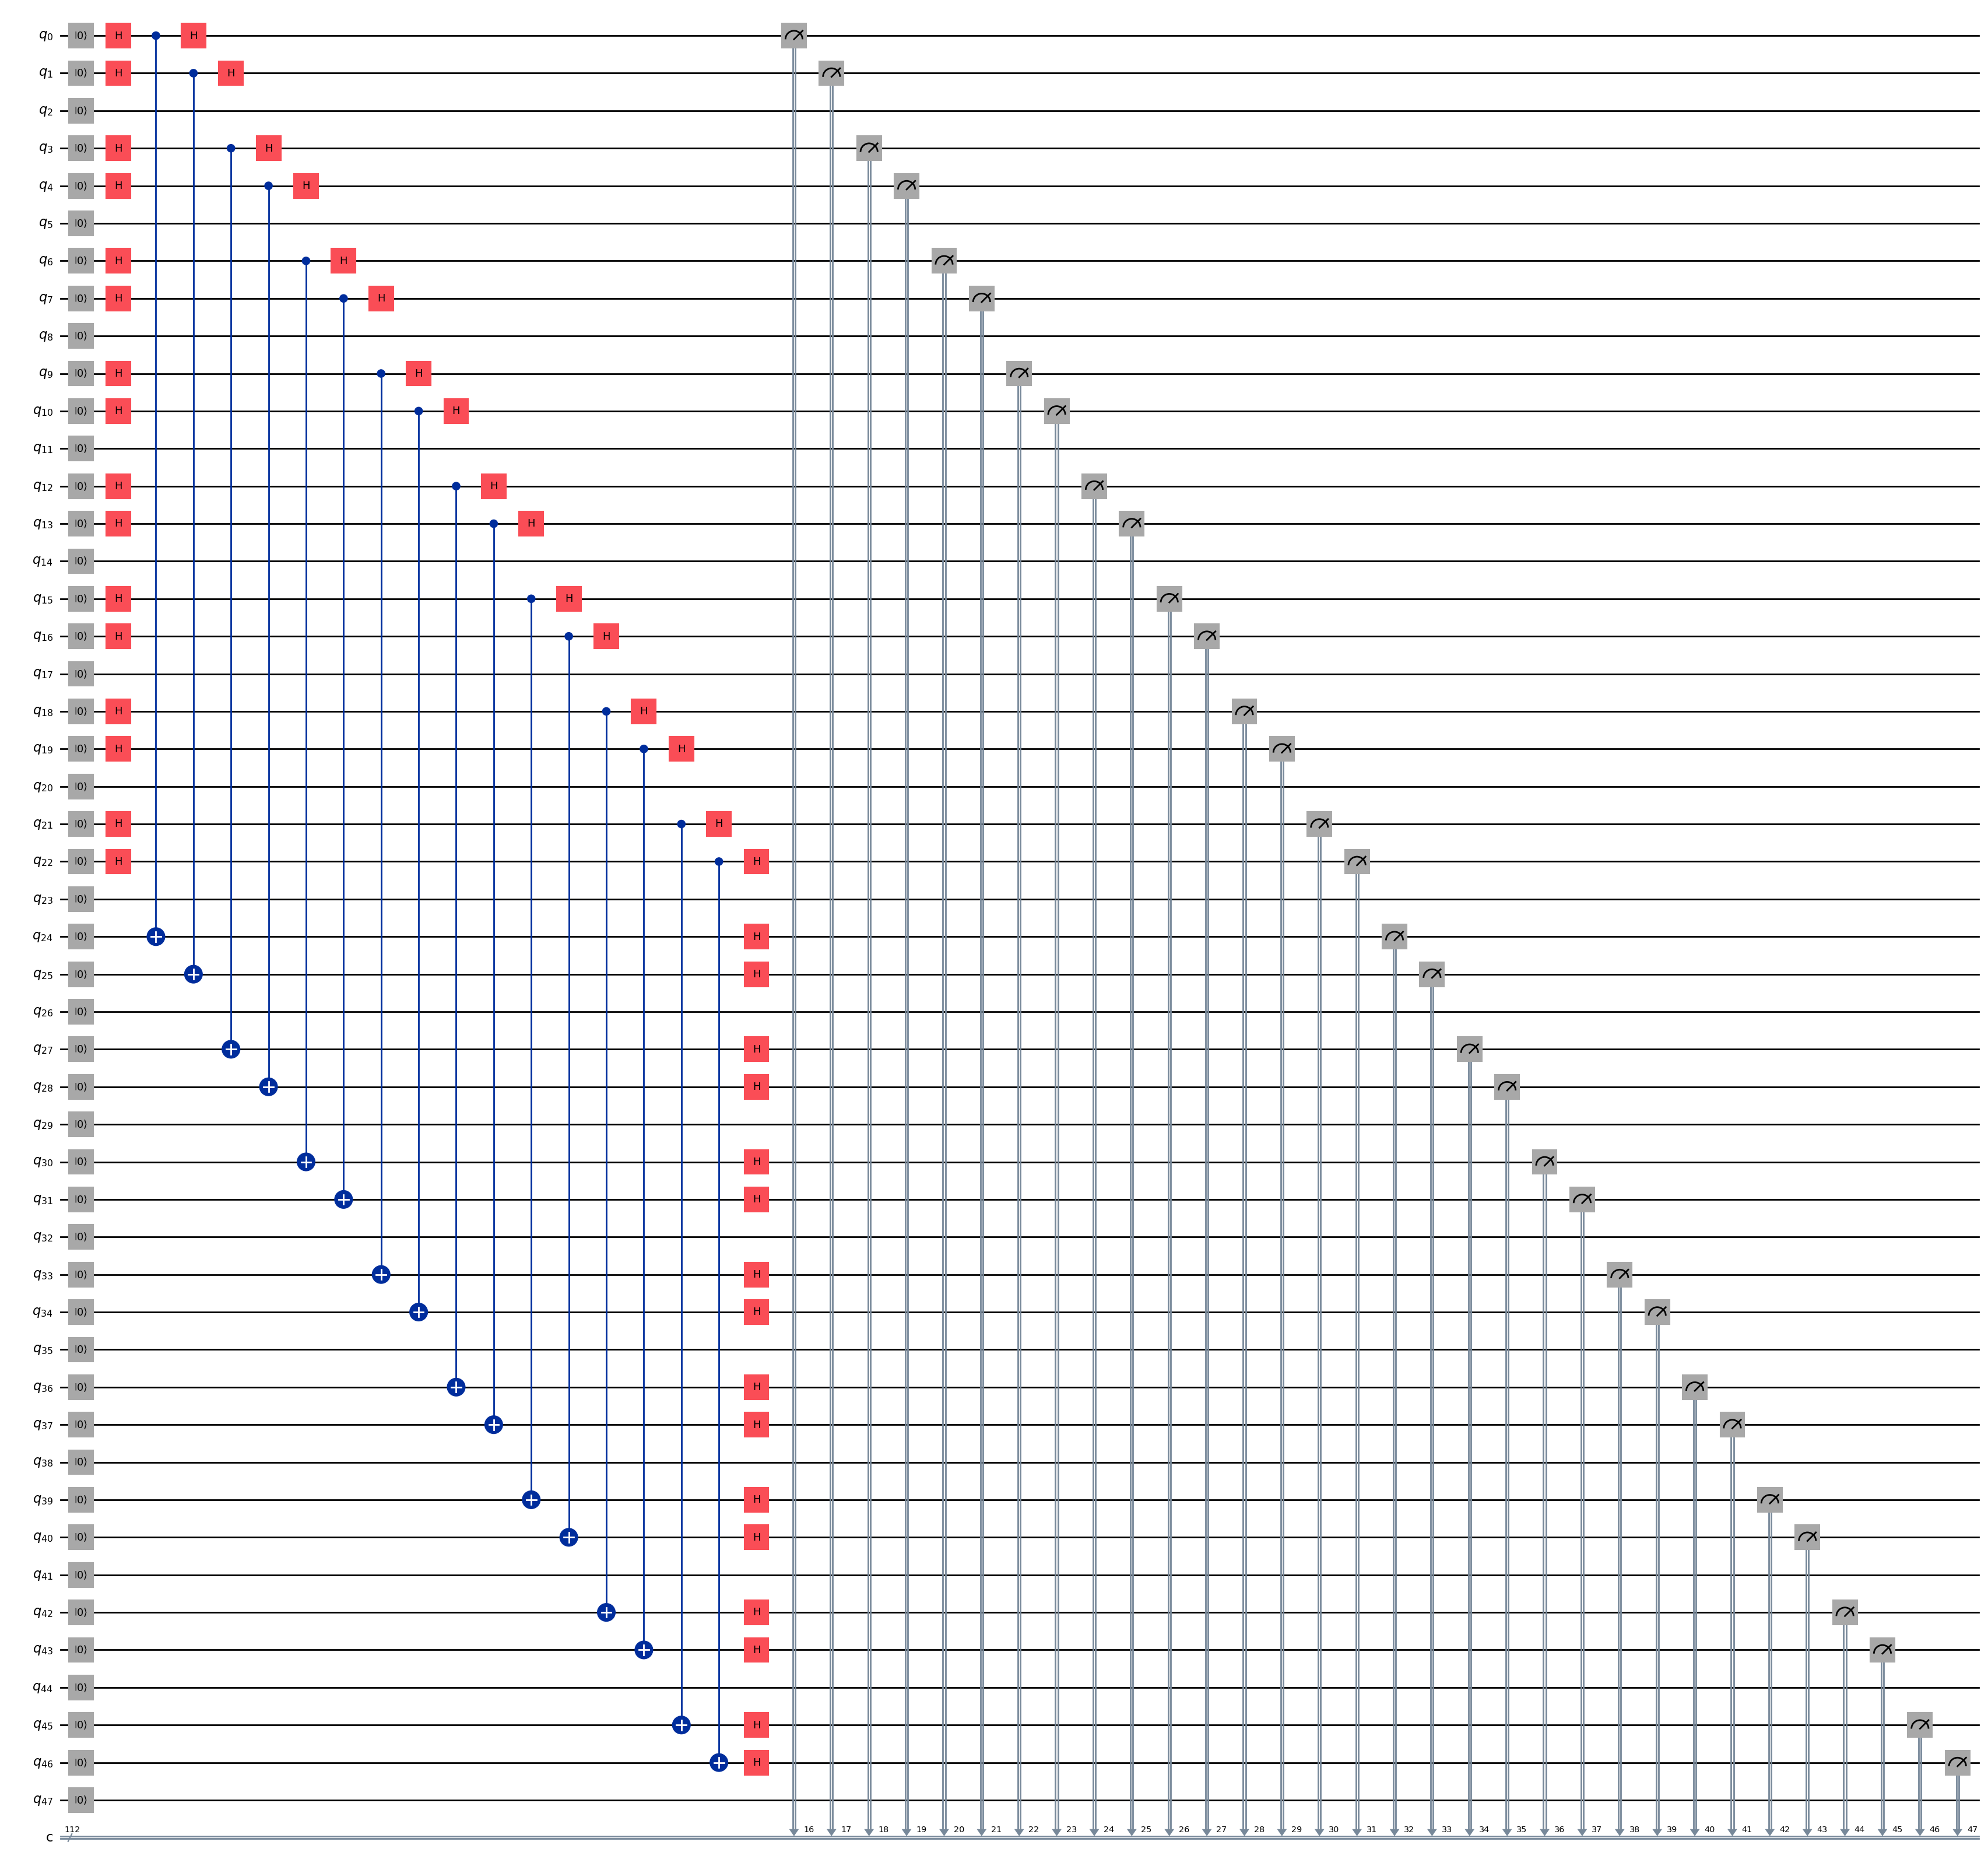

In [124]:
n = 5
lstate = "x"
sim_type = "m1"
i = 17

meas_type = convert_i_to_meas_type(i, n, lstate)
x_ind = 0
for idx, m_type in enumerate(meas_type):
    if m_type == "x":
        x_ind = idx
        break

print(x_ind, meas_type)

qc = generate_qiskit_polar_code_with_error_detection(n, lstate, sim_type, i)
qc.draw("mpl", fold=-1)

In [125]:
best_cx = 9999
best_tqc = None
best_layout = None

print("ibm_torino")
for j in range(1):
    tqc = pm_3_new_na_cx_torino.run(qc)
    tmp_cx = tqc.count_ops()["cx"]
    initial_layout = tqc.layout.initial_index_layout(filter_ancillas=True)

    if best_cx > tmp_cx:
        best_cx = tmp_cx
        best_tqc = tqc
        best_layout = initial_layout
        
        
        print(j, tmp_cx, initial_layout)

print("best cx = ", best_cx, best_layout)

# Assuming best_tqc is your transpiled QuantumCircuit
used_cx_edges = set()   # Use a set to store unique pairs (edges)
used_cx_qubits = set()  # Use a set to store unique individual qubits
used_measurement_qubits = []

# Iterate through every instruction in the circuit
for instruction in best_tqc.data:
    # Check if the operation is a CNOT
    if instruction.operation.name == 'cx':
        # specific methods to get the integer index of the qubit
        # .find_bit() is the safest way in modern Qiskit to get the index
        q1_index = best_tqc.find_bit(instruction.qubits[0]).index
        q2_index = best_tqc.find_bit(instruction.qubits[1]).index
        
        # Add to our tracking sets
        used_cx_edges.add(tuple(sorted((q1_index, q2_index))))
        used_cx_qubits.add(q1_index)
        used_cx_qubits.add(q2_index)
    elif instruction.operation.name == 'measure':
        q1_index = best_tqc.find_bit(instruction.qubits[0]).index
        used_measurement_qubits.append(q1_index)
    
print(f"Unique Physical Qubits involved in CX: {sorted(list(used_cx_qubits))}")
print(f"Unique Hardware Edges used: {sorted(list(used_cx_edges))}")
print(f"Unique Physical Qubits involved in Measurement: {sorted(list(used_measurement_qubits))}")

ibm_torino
0 16 [4, 5, 72, 16, 2, 117, 7, 22, 87, 24, 0, 93, 9, 17, 92, 20, 34, 51, 35, 28, 18, 54, 66, 37, 3, 6, 36, 23, 1, 91, 8, 21, 74, 25, 15, 112, 10, 27, 131, 19, 40, 68, 44, 29, 60, 61, 65, 132]
best cx =  16 [4, 5, 72, 16, 2, 117, 7, 22, 87, 24, 0, 93, 9, 17, 92, 20, 34, 51, 35, 28, 18, 54, 66, 37, 3, 6, 36, 23, 1, 91, 8, 21, 74, 25, 15, 112, 10, 27, 131, 19, 40, 68, 44, 29, 60, 61, 65, 132]
Unique Physical Qubits involved in CX: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 34, 35, 40, 44, 54, 61, 65, 66]
Unique Hardware Edges used: [(0, 15), (1, 2), (3, 4), (5, 6), (7, 8), (9, 10), (16, 23), (17, 27), (19, 20), (21, 22), (24, 25), (28, 29), (34, 40), (35, 44), (54, 61), (65, 66)]
Unique Physical Qubits involved in Measurement: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 34, 35, 40, 44, 54, 61, 65, 66]


In [126]:
best_cx = 9999
best_tqc = None
best_layout = None

print("ibm_marrakesh")
for j in range(1):
    tqc = pm_3_new_na_cx_marrakesh.run(qc)
    tmp_cx = tqc.count_ops()["cx"]
    initial_layout = tqc.layout.initial_index_layout(filter_ancillas=True)

    if best_cx > tmp_cx:
        best_cx = tmp_cx
        best_tqc = tqc
        best_layout = initial_layout
        
        
        print(j, tmp_cx, initial_layout)

print("best cx = ", best_cx, best_layout)

# Assuming best_tqc is your transpiled QuantumCircuit
used_cx_edges = set()   # Use a set to store unique pairs (edges)
used_cx_qubits = set()  # Use a set to store unique individual qubits
used_measurement_qubits = []

# Iterate through every instruction in the circuit
for instruction in best_tqc.data:
    # Check if the operation is a CNOT
    if instruction.operation.name == 'cx':
        # specific methods to get the integer index of the qubit
        # .find_bit() is the safest way in modern Qiskit to get the index
        q1_index = best_tqc.find_bit(instruction.qubits[0]).index
        q2_index = best_tqc.find_bit(instruction.qubits[1]).index
        
        # Add to our tracking sets
        used_cx_edges.add(tuple(sorted((q1_index, q2_index))))
        used_cx_qubits.add(q1_index)
        used_cx_qubits.add(q2_index)
    elif instruction.operation.name == 'measure':
        q1_index = best_tqc.find_bit(instruction.qubits[0]).index
        used_measurement_qubits.append(q1_index)
    
print(f"Unique Physical Qubits involved in CX: {sorted(list(used_cx_qubits))}")
print(f"Unique Hardware Edges used: {sorted(list(used_cx_edges))}")
print(f"Unique Physical Qubits involved in Measurement: {sorted(list(used_measurement_qubits))}")

ibm_marrakesh
0 16 [3, 4, 19, 16, 1, 148, 6, 22, 146, 24, 8, 34, 17, 36, 155, 37, 10, 134, 28, 44, 12, 14, 109, 139, 2, 5, 66, 23, 0, 107, 7, 21, 85, 25, 9, 114, 27, 41, 15, 45, 11, 153, 29, 43, 77, 13, 110, 154]
best cx =  16 [3, 4, 19, 16, 1, 148, 6, 22, 146, 24, 8, 34, 17, 36, 155, 37, 10, 134, 28, 44, 12, 14, 109, 139, 2, 5, 66, 23, 0, 107, 7, 21, 85, 25, 9, 114, 27, 41, 15, 45, 11, 153, 29, 43, 77, 13, 110, 154]
Unique Physical Qubits involved in CX: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 16, 17, 21, 22, 23, 24, 25, 27, 28, 29, 36, 37, 41, 43, 44, 45, 109, 110]
Unique Hardware Edges used: [(0, 1), (2, 3), (4, 5), (6, 7), (8, 9), (10, 11), (13, 14), (16, 23), (17, 27), (21, 22), (24, 25), (28, 29), (36, 41), (37, 45), (43, 44), (109, 110)]
Unique Physical Qubits involved in Measurement: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 16, 17, 21, 22, 23, 24, 25, 27, 28, 29, 36, 37, 41, 43, 44, 45, 109, 110]


In [127]:
best_cx = 9999
best_tqc = None
best_layout = None

print("ibm_fez")
for j in range(1):
    tqc = pm_3_new_na_cx_fez.run(qc)
    tmp_cx = tqc.count_ops()["cx"]
    initial_layout = tqc.layout.initial_index_layout(filter_ancillas=True)

    if best_cx > tmp_cx:
        best_cx = tmp_cx
        best_tqc = tqc
        best_layout = initial_layout
        
        
        print(j, tmp_cx, initial_layout)

print("best cx = ", best_cx, best_layout)

# Assuming best_tqc is your transpiled QuantumCircuit
used_cx_edges = set()   # Use a set to store unique pairs (edges)
used_cx_qubits = set()  # Use a set to store unique individual qubits
used_measurement_qubits = []

# Iterate through every instruction in the circuit
for instruction in best_tqc.data:
    # Check if the operation is a CNOT
    if instruction.operation.name == 'cx':
        # specific methods to get the integer index of the qubit
        # .find_bit() is the safest way in modern Qiskit to get the index
        q1_index = best_tqc.find_bit(instruction.qubits[0]).index
        q2_index = best_tqc.find_bit(instruction.qubits[1]).index
        
        # Add to our tracking sets
        used_cx_edges.add(tuple(sorted((q1_index, q2_index))))
        used_cx_qubits.add(q1_index)
        used_cx_qubits.add(q2_index)
    elif instruction.operation.name == 'measure':
        q1_index = best_tqc.find_bit(instruction.qubits[0]).index
        used_measurement_qubits.append(q1_index)
    
print(f"Unique Physical Qubits involved in CX: {sorted(list(used_cx_qubits))}")
print(f"Unique Hardware Edges used: {sorted(list(used_cx_edges))}")
print(f"Unique Physical Qubits involved in Measurement: {sorted(list(used_measurement_qubits))}")

ibm_fez
0 16 [3, 4, 50, 16, 1, 90, 6, 22, 132, 24, 8, 136, 17, 36, 74, 37, 10, 64, 28, 46, 106, 114, 143, 110, 2, 5, 70, 23, 0, 14, 7, 21, 97, 25, 9, 120, 27, 41, 88, 45, 11, 48, 29, 47, 154, 115, 142, 148]
best cx =  16 [3, 4, 50, 16, 1, 90, 6, 22, 132, 24, 8, 136, 17, 36, 74, 37, 10, 64, 28, 46, 106, 114, 143, 110, 2, 5, 70, 23, 0, 14, 7, 21, 97, 25, 9, 120, 27, 41, 88, 45, 11, 48, 29, 47, 154, 115, 142, 148]
Unique Physical Qubits involved in CX: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 16, 17, 21, 22, 23, 24, 25, 27, 28, 29, 36, 37, 41, 45, 46, 47, 114, 115, 142, 143]
Unique Hardware Edges used: [(0, 1), (2, 3), (4, 5), (6, 7), (8, 9), (10, 11), (16, 23), (17, 27), (21, 22), (24, 25), (28, 29), (36, 41), (37, 45), (46, 47), (114, 115), (142, 143)]
Unique Physical Qubits involved in Measurement: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 16, 17, 21, 22, 23, 24, 25, 27, 28, 29, 36, 37, 41, 45, 46, 47, 114, 115, 142, 143]


In [128]:
len(used_qubits(best_tqc))

32

In [129]:
# best_tqc.draw(fold=-1)

In [130]:
def check_for_mismatch(syndrome_bits, n, x_ind, detection_layer = 1):
    """
    Helper function to check for a pattern mismatch in the measurement record.
    Returns True if a mismatch is found, False otherwise.
    d_layer = detection layer
    """
    expected_length = 2**(n - 1)
    
    full_bitstring = ''.join(['1' if b else '0' for b in syndrome_bits])
    # print(syndrome_bits, full_bitstring)
    
    # Extract the relevant portion of the syndrome for this layer.
    start_index = expected_length * detection_layer
    syndrome_to_check = full_bitstring[start_index:]
    
    bit_gap = 2**x_ind

    # print(len(full_bitstring), full_bitstring, syndrome_to_check, expected_length, bit_gap, x_ind)
    
    for i in range(expected_length):
        if (i % (2 * bit_gap)) < bit_gap:
            j = i + bit_gap
            if syndrome_to_check[i] != syndrome_to_check[j]:
                print(f"Mismatch found at indices ({i}, {j}) for string {syndrome_to_check}.")
                return True
            
    return False

In [131]:
def rearrange_bits(bit_string, m_order):
    
    new_bits = [''] * len(bit_string)

    # Loop through each bit in the original string
    for j in range(len(bit_string)):
        # Get the bit from the original string
        original_bit = bit_string[j]
        
        # Get the new position for this bit from the order list
        new_position = m_order[j]
        
        # Place the bit in its new position
        new_bits[new_position] = original_bit

    reordered_string = "".join(new_bits)[::-1]

    return reordered_string

In [132]:
def simulate_stim_one_shot_qiskit(tqc, n, sim_type, backend, p_error, x_ind, seed):
    dag = circuit_to_dag(tqc)
    
    sim = stim.TableauSimulator(seed=seed)
    m_order = []

    if sim_type in ["m1", "m2"]:
        for idx in range(2**(n - 1)):
            m_order.append(idx)
            sim.measure(idx)

    t1, t2, error_1q, readout_error, error_2q = get_backend_information(backend)

    # Initialize Error
    used_qbs = used_qubits(tqc)
    for qb in used_qbs:
        error_rate = error_1q[qb] * p_error
        sim.x_error(qb, p=error_rate)

    for idx, layer in enumerate(dag.layers()):
        layer_as_circuit = dag_to_circuit(layer['graph']) 

        for g in layer_as_circuit:
            
            op = g.operation
            qbits = g.qubits
            cbits = g.clbits
            qb1 = qbits[0]._index
            
            if op.num_qubits == 1:
                # print(op.name, op.num_qubits, qbits[0]._index)
                if op.name == "h":
                    error_rate = error_1q[qb1] * p_error
                    sim.h(qb1)
                    sim.depolarize1(qb1, p=error_rate)
                    
                    
                elif op.name == "reset":
                    error_rate = error_1q[qb1] * p_error
                    sim.reset(qb1)
                    sim.x_error(qb1, p=error_rate)

                elif op.name == "measure":
                    error_rate = readout_error[qb1] * p_error

                    sim.x_error(qb1, p=error_rate)
                    sim.measure(qb1)
                    m_order.append(cbits[0]._index)
                    
            elif op.name == "barrier":
                # Here is the error detection
                cms = sim.current_measurement_record()
                # print(cms)

                detection_layer = 1
                if sim_type == "m2":
                    detection_layer -=1

                bit_string = ''.join(['1' if b else '0' for b in cms])
                reordered_string = rearrange_bits(bit_string, m_order)
                cms = [char == '1' for char in reordered_string]

                if check_for_mismatch(cms, n, x_ind, detection_layer):
                    return "", ""
            
                # print(op, op.name)
            else:
                qb2 = qbits[1]._index
                error_rate = error_2q[(qb1, qb2)] * p_error

                if op.name == "cx":
                    sim.cx(qb1, qb2)
                    sim.depolarize2(qb1,qb2, p=error_rate)
                elif op.name == "swap":
                    sim.cx(qb1, qb2)
                    sim.depolarize2(qb1,qb2, p=error_rate)
                    sim.cx(qb2, qb1)
                    sim.depolarize2(qb1,qb2, p=error_rate)
                    sim.cx(qb1, qb2)
                    sim.depolarize2(qb1,qb2, p=error_rate)

    final_measurements = sim.current_measurement_record()

    # Generate the bit string, reverse it, and update the counts.
    bit_string = ''.join(['1' if b else '0' for b in final_measurements])

    return bit_string, m_order

    


In [133]:
sim_type = "m2"
p_error = 0

count_detect_discard = 0
count = collections.Counter()


meas_type = convert_i_to_meas_type(i, n, lstate)
x_ind = 0
for idx, m_type in enumerate(meas_type):
    if m_type == "x":
        x_ind = idx
        break

print(x_ind, meas_type)

for seed in range(10):
    res, m_order = simulate_stim_one_shot_qiskit(best_tqc, n, sim_type, backend, p_error, x_ind, seed)
    
    if res == "":
        count_detect_discard += 1
        continue

    reordered_string = rearrange_bits(res, m_order)

    # print(m_order, res, bit_string, reordered_string)

    count.update([reordered_string])
    # count.update([res])



zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
zpos_list[n] = i-1

count_accept, _, _, sc, _, _ = get_logical_error_on_accepted_states(n, lstate.upper(), count, zpos_list)

print(count_accept, sc, count_detect_discard)


4 ['z', 'z', 'z', 'z', 'x']
10 1.0 0


In [134]:
def simulate_circuit_polar_stim_tableau_from_qiskit(n, lstate, sim_type, i, p_error, seed, shots, backend, comp_type
                            ):

    count_detect_discard = 0
    count = collections.Counter()

    meas_type = convert_i_to_meas_type(i, n, lstate)
    
    x_ind = 0
    for idx, m_type in enumerate(meas_type):
        if m_type == "x":
            x_ind = idx
            break

    # qc = generate_qiskit_polar_code(n, lstate.lower(), sim_type, i)
    qc = generate_qiskit_polar_code_with_error_detection(n, lstate.lower(), sim_type, i)
    tqc = None
    if comp_type == "na":
        pm_na = create_sabre_na_pm(backend, 3, seed)

        best_cx = 9999
        best_tqc = None
        best_layout = None
        best_idx = 9999

        for j in range(2):
            tmp_tqc = pm_na.run(qc)
            tmp_cx = tmp_tqc.count_ops()["cx"]
            initial_layout = tmp_tqc.layout.initial_index_layout(filter_ancillas=True)

            if best_cx > tmp_cx:
                best_cx = tmp_cx
                best_tqc = tmp_tqc
                best_layout = initial_layout
                best_idx = j
                
        tqc = best_tqc
        print(f"[NA-{i}] best_idx = ", best_idx, ", best cx = ", best_cx)
    else:
        best_cx = 9999
        best_tqc = None
        best_layout = None
        best_idx = 9999

        for j in range(2):
            tmp_tqc = compiled_to_qiskit_hardware(qc, backend, 3, seed)
            tmp_cx = tmp_tqc.count_ops()["cx"]
            initial_layout = tmp_tqc.layout.initial_index_layout(filter_ancillas=True)

            if best_cx > tmp_cx:
                best_cx = tmp_cx
                best_tqc = tmp_tqc
                best_layout = initial_layout
                best_idx = j
                
        tqc = best_tqc
        print(f"[init-{i}] best_idx = ", best_idx, ", best cx = ", best_cx)
    
    seeds = range(seed, seed + shots)
    for s in seeds:
        res, m_order = simulate_stim_one_shot_qiskit(tqc, n, sim_type, backend, p_error, x_ind, s)

        if res == "":
            count_detect_discard += 1
            continue

        new_bits = [''] * len(res)
        for j in range(len(res)):
            original_bit = res[j]
            new_position = m_order[j]
            new_bits[new_position] = original_bit
        reordered_string = "".join(new_bits)[::-1]
        count.update([reordered_string])
    
    

    return count, count_detect_discard

In [135]:
n = 4
lstate = "z"
sim_type = "m2"
p_error = 0
seed = random.randint(1, 9999999)
comp_type = "na"
shots = 100

# for i in range(2, (2**n)+1):
i = 2

meas_type = convert_i_to_meas_type(i, n, lstate)
x_ind = 0
for idx, m_type in enumerate(meas_type):
    if m_type == "x":
        x_ind = idx
        break

print(x_ind, meas_type)

count, count_detect_discard = simulate_circuit_polar_stim_tableau_from_qiskit(n, lstate, sim_type, i, p_error, seed, shots, backend, comp_type)
                            
zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
zpos_list[n] = i-1

count_accept, _, _, sc, _, _ = get_logical_error_on_accepted_states(n, lstate.upper(), count, zpos_list)

print(i, count_accept, sc, count_detect_discard)

1 ['z', 'x', 'x', 'x']
Mapping properties from native 'cz' to 'cx'...


KeyboardInterrupt: 

In [ ]:
from wrappers.stim_wrapper import compiled_to_qiskit_hardware

tqc_2 = compiled_to_qiskit_hardware(qc, backend, 3, seed)
tqc_2.draw(fold=-1)

/home/handy/Github/quantum_platform/wrappers/stim_wrapper/stim_wrapper.py:939: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm_2 = generate_preset_pass_manager(


┌───┐┌───┐                                                             ┌─┐                                    
  q_28 -> 0 ─|0>──────┤ X ├┤ H ├─────────────────────────────────────────────────────────────┤M├────────────────────────────────────
                 ┌───┐└─┬─┘├───┤                   ┌─┐                                       └╥┘                                    
   q_4 -> 1 ─|0>─┤ H ├──■──┤ H ├───────────────────┤M├────────────────────────────────────────╫─────────────────────────────────────
                 └───┘┌───┐├───┤                   └╥┘                              ┌─┐       ║                                     
  q_24 -> 2 ─|0>──────┤ X ├┤ H ├────────────────────╫───────────────────────────────┤M├───────╫─────────────────────────────────────
                 ┌───┐└─┬─┘├───┤          ┌─┐       ║                               └╥┘       ║                                     
   q_0 -> 3 ─|0>─┤ H ├──■──┤ H ├──────────┤M├───────╫────────────────────────────────╫────────╫─────────────────────────────────────
                 ├───┤     ├───┤          └╥┘┌─┐    ║                                ║        ║                                     
   q_1 -> 4 ─|0>─┤ H ├──■──┤ H ├───────────╫─┤M├────╫────────────────────────────────╫────────╫─────────────────────────────────────
                 └───┘┌─┴─┐├───┤           ║ └╥┘    ║                                ║ ┌─┐    ║                                     
  q_25 -> 5 ─|0>──────┤ X ├┤ H ├───────────╫──╫─────╫────────────────────────────────╫─┤M├────╫─────────────────────────────────────
                 ┌───┐└───┘├───┤           ║  ║     ║ ┌─┐                            ║ └╥┘    ║                                     
   q_6 -> 6 ─|0>─┤ H ├──■──┤ H ├───────────╫──╫─────╫─┤M├────────────────────────────╫──╫─────╫─────────────────────────────────────
                 └───┘┌─┴─┐├───┤           ║  ║     ║ └╥┘                            ║  ║     ║ ┌─┐                                 
  q_30 -> 7 ─|0>──────┤ X ├┤ H ├───────────╫──╫─────╫──╫─────────────────────────────╫──╫─────╫─┤M├─────────────────────────────────
                 ┌───┐└───┘├───┤           ║  ║     ║  ║       ┌─┐                   ║  ║     ║ └╥┘                                 
  q_10 -> 8 ─|0>─┤ H ├──■──┤ H ├───────────╫──╫─────╫──╫───────┤M├───────────────────╫──╫─────╫──╫──────────────────────────────────
                 └───┘┌─┴─┐├───┤           ║  ║     ║  ║       └╥┘                   ║  ║     ║  ║       ┌─┐                        
  q_34 -> 9 ─|0>──────┤ X ├┤ H ├───────────╫──╫─────╫──╫────────╫────────────────────╫──╫─────╫──╫───────┤M├────────────────────────
                 ┌───┐└───┘├───┤           ║  ║     ║  ║        ║       ┌─┐          ║  ║     ║  ║       └╥┘                        
 q_16 -> 10 ─|0>─┤ H ├──■──┤ H ├───────────╫──╫─────╫──╫────────╫───────┤M├──────────╫──╫─────╫──╫────────╫─────────────────────────
                 └───┘┌─┴─┐├───┤           ║  ║     ║  ║        ║       └╥┘          ║  ║     ║  ║        ║          ┌─┐            
 q_40 -> 11 ─|0>──────┤ X ├┤ H ├───────────╫──╫─────╫──╫────────╫────────╫───────────╫──╫─────╫──╫────────╫──────────┤M├────────────
                      └───┘└───┘           ║  ║     ║  ║        ║        ║           ║  ║     ║  ║        ║          └╥┘            
 q_23 -> 14 ─|0>───────────────────────────╫──╫─────╫──╫────────╫────────╫───────────╫──╫─────╫──╫────────╫───────────╫─────────────
                 ┌───┐          ┌───┐      ║  ║ ┌─┐ ║  ║        ║        ║           ║  ║     ║  ║        ║           ║             
  q_3 -> 16 ─|0>─┤ H ├───────■──┤ H ├──────╫──╫─┤M├─╫──╫────────╫────────╫───────────╫──╫─────╫──╫────────╫───────────╫─────────────
                 ├───┤       │  └───┘┌───┐ ║  ║ └╥┘ ║  ║        ║ ┌─┐    ║           ║  ║     ║  ║        ║           ║             
 q_12 -> 17 ─|0>─┤ H ├───────┼────■──┤ H ├─╫──╫──╫──╫──╫────────╫─┤M├────╫───────────╫──╫─────╫──╫────────╫───────────╫─────────────
                 └───┘┌───┐  │  

# Run to Real Backend

In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.options import SamplerOptions

options = SamplerOptions(
            default_shots=1e4
             )

hw_name = "ibm_marrakesh"
backend = service.backend(hw_name)

pm = generate_preset_pass_manager(
    optimization_level=3, backend=backend
    #, seed_transpiler=12345
    )

sampler = Sampler(mode=backend, options=options) 

In [ ]:
def generate_polar_qiskit_pubs(n, lstate, i_values, sim_type):

    circuits = []
    for i in i_values:
        qc = generate_qiskit_polar_code(n, lstate.lower(), sim_type, i, skip_reset=True)
        # qc_m1 = generate_qiskit_polar_code(n, lstate.lower(), "m1", i, skip_reset=True)

        circuits.append(qc)
        # circuits.append(qc_m1)


    pubs = pm.run(circuits)

    return pubs

def fix_result_order(n, lstate, i, counts):
    meas_type = convert_i_to_meas_type(i, n, lstate)
    ancilla_qubits = 2**(n - 1)
    zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
    zpos_list[n] = i-1

    x_ind = 0
    for idx, m_type in enumerate(meas_type):
        if m_type == "x":
            x_ind = idx
            break

    if x_ind > 0:
        new_counts = {}
        for key, value in counts.items():
            new_key = (key + "0"*ancilla_qubits*x_ind)[ancilla_qubits*x_ind:]
            # print(key, new_key, value, "0"*ancilla_qubits*x_ind)
            new_counts[new_key] = value

        return new_counts
    else:
        return counts

    

In [ ]:
# n = 3
# lstate = "x"
# i_values = [2, 3, 5]

n = 4
lstate = "z"
i_values = [8, 12, 14, 15]

sim_type = "normal"
pubs_n = generate_polar_qiskit_pubs(n, lstate, i_values, sim_type)

sim_type = "m1"
pubs_m1 = generate_polar_qiskit_pubs(n, lstate, i_values, sim_type)



In [ ]:
# pubs_m1[0].draw(fold=-1)

In [ ]:
# n = 3
# lstate = "x"
# shots = 100
# i = i_values[0]

# counts = sim_ideal.run(pubs_n[0], shots = shots).result().get_counts()
# counts = fix_result_order(n, lstate, i, counts)


# zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
# zpos_list[n] = i-1
# count_accept, _, _, sc, _, _ = get_logical_error_on_accepted_states(n, lstate.upper(), counts, zpos_list)

# print(count_accept, 1-sc)

In [ ]:
# n = 3
# i = 5
# lstate = "x"
# shots = 10
# qc = generate_qiskit_polar_code(n, lstate.lower(), "normal", i, skip_reset=True)
# tmp_counts = sim_ideal.run(qc, shots = shots).result().get_counts()
# counts = fix_result_order(n, lstate, i, tmp_counts)

# zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
# zpos_list[n] = i-1

# count_accept, _, _, sc, _, _ = get_logical_error_on_accepted_states(n, lstate.upper(), counts, zpos_list)
# print(count_accept, 1-sc)
# # qc.draw("mpl", fold=-1)

In [ ]:
# job = sampler.run(pubs_n)
# print(hw_name, "normal", job.job_id())

# job = sampler.run(pubs_m1)
# print(hw_name, "m1", job.job_id())




ibm_marrakesh normal d72e1dhamkec73a15lp0
ibm_marrakesh m1 d72e1duqdfbc73d23f60


In [ ]:
# n = 4, lstate = z, i_values = [8, 12, 14, 15], shots = 1e4 normal
# ibm_marrakesh normal d6bi28h54hss73b7cmk0 17s -- saved
# ibm_marrakesh normal d6bi37fg4t5c7384cs10 16s -- saved
# ibm_marrakesh normal d6bi4m17ce2c73ffeejg 16s -- saved
# ibm_marrakesh normal d72e1dhamkec73a15lp0 13s -- saved

# n = 4, lstate = z, i_values = [8, 12, 14, 15], shots = 1e4 m1
# ibm_marrakesh m1 d6bi28knsg9c73991f80 15s -- saved
# ibm_marrakesh m1 d6bi37ng4t5c7384cs1g 15s -- saved
# ibm_marrakesh m1 d6bi4mfg4t5c7384cthg 15s -- saved
# ibm_marrakesh m1 d72e1duqdfbc73d23f60 13s -- saved

In [ ]:
# n = 4, lstate = x, i_values = [2, 9], shots = 1e4 normal
# ibm_marrakesh normal d6bhqjcnsg9c739916i0 9s -- saved
# ibm_marrakesh normal d6bhtgsnsg9c73991a40 9s -- saved
# ibm_marrakesh normal d6bhu0fg4t5c7384cmgg 9s -- saved
# ibm_marrakesh normal d6bhu6vg4t5c7384cmn0 9s -- saved

# n = 4, lstate = x, i_values = [2, 9], shots = 1e4 m1
# ibm_marrakesh m1 d6bhqjh54hss73b7cdo0 8s -- saved
# ibm_marrakesh m1 d6bhth17ce2c73ffe780 8s -- saved
# ibm_marrakesh m1 d6bhu0h54hss73b7chsg 8s -- saved
# ibm_marrakesh m1 d6bhu7154hss73b7ci2g 8s -- saved

In [ ]:
# n = 3, lstate = x, i_values = [2, 3, 5], shots = 1e4 normal
# ibm_torino normal d44dvgpag40c7385o5m0 12s -- saved
# ibm_torino normal d44e1dlo35ts73c8koeg 10s -- saved
# ibm_torino normal d44e2apag40c7385o8g0 10s -- saved
# ibm_torino normal d44eg25o35ts73c8l6qg 10s -- saved
# ibm_torino normal d44egh90f7bc7389agc0 10s -- saved
# ibm_torino normal d44egr10f7bc7389agm0 19s -- saved 2e4
# ibm_torino normal d44fanto35ts73c8lvog 19s -- saved 2e4



# n = 3, lstate = x, i_values = [2, 3, 5], shots = 1e4 m1
# ibm_torino m1 d44dvh5o35ts73c8kmbg 11s  -- saved
# ibm_torino m1 d44e1dp0f7bc7389a1gg 10s  -- saved
# ibm_torino m1 d44e2b10f7bc7389a2d0 10s  -- saved
# ibm_torino m1 d44eg287i53s73e50hq0 10s -- saved
# ibm_torino m1 d44egh90f7bc7389agd0 10s -- saved
# ibm_torino m1 d44egr9ag40c7385omng 18s -- saved 2e4
# ibm_torino m1 d44fao1ag40c7385pf20 18s -- saved 2e4

# -----------------------------------

# n = 4, lstate = x, i_values = [2, 3, 5, 9], shots = 1e4 (combination between normal + m1)
# d44doro7i53s73e4vqr0 ibm_torino 33s 
# d44dp5do35ts73c8kflg ibm_torino 27s
# d44dpb87i53s73e4vra0 ibm_torino 29s

# n = 4, lstate = x, i_values = [2, 3, 5, 9], shots = 1e4 normal
# ibm_torino normal d44dsm07i53s73e4vuh0 21s -- saved
# ibm_torino normal d44dtk90f7bc73899th0 16s -- saved
# ibm_torino normal d44du3lo35ts73c8kkqg 15s -- saved
# ibm_torino normal d44e7n90f7bc7389a87g 15s -- saved
# ibm_torino normal d44e8u5o35ts73c8l03g 16s -- saved
# ibm_torino normal d44fbig7i53s73e51bd0 28s 2e4 -- saved
# ibm_torino normal d44fcq9ag40c7385pgug 1m 8s 5e4 -- saved



# n = 4, lstate = x, i_values = [2, 3, 5, 9], shots = 1e4 m1
# ibm_torino m1 d44dsm90f7bc73899sjg 14s -- saved
# ibm_torino m1 d44dtkhag40c7385o3bg 14s -- saved
# ibm_torino m1 d44du3pag40c7385o400 14s -- saved
# ibm_torino m1 d44e7nlo35ts73c8kv00 14s -- saved
# ibm_torino m1 d44e8u90f7bc7389a9c0 14s -- saved
# ibm_torino m1 d44fbip0f7bc7389b9i0 26s 2e4 -- saved
# ibm_torino m1 d44fcqdo35ts73c8m1l0 1m2s 5e4 -- saved

In [ ]:
import json 
import os
import sys

def save_results_to_file(hw_name, n, lstate, sim_type, job_ids, service):
    # Result Type:
    # m1 : only first layer update the xx measurement
    
    for job_id in job_ids:
        job = service.job(job_id)
        result = job.result()
        
        with open(f"output/{hw_name}_n{n}_{lstate}/result_{sim_type}_{job_id}.json", "w") as file:
            json.dump(result, file, cls=RuntimeEncoder)

def load_results_from_file(hw_name, n, lstate, sim_type):
    folder_path = f'output/{hw_name}_n{n}_{lstate}/'
    files = [f for f in os.listdir(folder_path) if f.startswith(f"result_{sim_type}_")]
    results = []

    for file_name in files:
        with open(f"output/{hw_name}_n{n}_{lstate}/{file_name}", "r") as file:
            result = json.load(file, cls=RuntimeDecoder)

        results.append(result)

    return results


In [ ]:
# n = 3
# lstate = "x"
# sim_type = "normal"
# job_ids = ["d44fanto35ts73c8lvog"]


# save_results_to_file(hw_name, n, lstate, sim_type, job_ids, service)

# n = 3
# lstate = "x"
# sim_type = "m1"
# job_ids = ["d44fao1ag40c7385pf20"]

# save_results_to_file(hw_name, n, lstate, sim_type, job_ids, service)

n = 4
lstate = "z"
sim_type = "normal"
job_ids = ["d72e1dhamkec73a15lp0"]

save_results_to_file(hw_name, n, lstate, sim_type, job_ids, service)

n = 4
lstate = "z"
sim_type = "m1"
job_ids = ["d72e1duqdfbc73d23f60"]

save_results_to_file(hw_name, n, lstate, sim_type, job_ids, service)

/home/handy/Github/quantum_platform/.venv/lib/python3.13/site-packages/qiskit_ibm_runtime/api/auth.py:67: UserWarning: Unable to retrieve IBM Cloud access token. API Key will be used instead. Error: Provided API key is disabled., Status code: 400
  warnings.warn(


IBMNotAuthorizedError: '401 Client Error: Unauthorized for url: https://quantum.cloud.ibm.com/api/v1/jobs/d72e1dhamkec73a15lp0. {"errors":[{"code":1219,"message":"Error authenticating user.","solution":"Your IBM Quantum API token might be incorrect, expired, or revoked.\\nLog in to IBM Quantum Platform website and navigate to your account settings to generate a new API token.\\nUse IBMProvider.save_account(`APIKEY`, overwrite=True) to save the new API key, overwriting any outdated or incorrect credentials.","more_info":"https://cloud.ibm.com/apidocs/quantum-computing#error-handling"}],"trace":"cd09ac46-beb2-48b5-8ef4-89e749f397a0"}'

In [ ]:
def processed_result_from_real_backend(hw_name, n, lstate, sim_type, i_values):
    results = load_results_from_file(hw_name, n, lstate, sim_type)

    # for res in results:
    #     print(res.metadata["execution"]["execution_spans"].duration)

    job_res = {}
    prep_rates = {}
    le_rates = {}

    for idx, i in enumerate(i_values):
        prep_rates[i] = []
        le_rates[i] = []

    for result in results:
        for idx, i in enumerate(i_values):
            tmp_counts = result[idx].data.c.get_counts()
            job_res[i] = fix_result_order(n, lstate, i, tmp_counts)

            shots = sum(job_res[i].values())

            zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
            zpos_list[n] = i-1


            count_accept, _, _, sc, _, _ = get_logical_error_on_accepted_states(n, lstate.upper(), job_res[i], zpos_list)
            # print(i, count_accept, 1-sc)

            prep_rates[i].append(count_accept/shots)
            le_rates[i].append(1-sc)
    
    return prep_rates, le_rates


In [ ]:
hw_name = "ibm_marrakesh"
n = 4
# lstate = "x"
# i_values = [2, 9]
lstate = "z"
i_values = [8, 12, 14, 15]

sim_type = "normal"
prep_rates_n, lers_n = processed_result_from_real_backend(hw_name, n, lstate, sim_type, i_values)

sim_type = "m1"
prep_rates_m1, lers_m1 = processed_result_from_real_backend(hw_name, n, lstate, sim_type, i_values)

In [ ]:
prep_rates_n, prep_rates_m1

({8: [1.0, 1.0, 1.0],
  12: [0.0629, 0.0728, 0.061],
  14: [0.0025, 0.0009, 0.002],
  15: [0.0001, 0.0, 0.0001]},
 {8: [1.0, 1.0, 1.0],
  12: [0.1078, 0.0643, 0.188],
  14: [0.0103, 0.0039, 0.0066],
  15: [0.0004, 0.0001, 0.0007]})

In [ ]:
print(lers_n)
print(lers_m1)

{8: [0.2863, 0.2976, 0.30500000000000005], 12: [0.5405405405405406, 0.3296703296703297, 0.38032786885245906], 14: [0.28, 0.4444444444444444, 0.30000000000000004], 15: [0.0, 1, 0.0]}
{8: [0.00019999999999997797, 0.0, 0.0], 12: [0.09276437847866414, 0.0746500777604977, 0.01648936170212767], 14: [0.07766990291262132, 0.2564102564102564, 0.0757575757575758], 15: [0.0, 0.0, 0.0]}
